# Assignment 11 — Attention Mechanisms

### Due: Monday, April 13, before class

Name(s): Chang Min Bark<br>
Course: CSCI 357 - AI and Neural Networks<br>
Section: 01 - 1:00pm<br>
Semester: Spring 2026<br>
Instructor: Prof. King<br>

### References

- Bahdanau, D., Cho, K., & Bengio, Y. (2015). Neural machine translation by jointly learning to align and translate. *ICLR 2015*.
- Vaswani, A., et al. (2017). Attention is all you need. *NeurIPS 2017*.
- Luong, M.-T., Pham, H., & Manning, C. D. (2015). Effective approaches to attention-based neural machine translation. *EMNLP 2015*.
- Jay Alammar's crazy good visuals and explanations for understanding machine learning concepts:
    - Jay Alammar. (2018). *The Illustrated Transformer*. https://jalammar.github.io/illustrated-transformer/
    - Jay Alammar. (2018). *Visualizing A Neural Machine Translation Model*. https://jalammar.github.io/visualizing-neural-machine-translation-mechanics-of-seq2seq-models-with-attention/
- Jain, S., & Wallace, B. C. (2019). Attention is not explanation. *NAACL 2019*.
- Wiegreffe, S., & Pinter, Y. (2019). Attention is not not explanation. *EMNLP 2019*.
- d2l.ai — Multi-Head Attention. https://d2l.ai/chapter_attention-mechanisms-and-transformers/multihead-attention.html
- Stanford CS224n — Self-Attention and Transformers Reading. https://web.stanford.edu/class/cs224n/readings/cs224n-self-attention-transformers-2023_draft.pdf


In [1]:
import sys
import os
import time
from enum import Enum
from functools import partial

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Basic configuration
torch.manual_seed(42)
np.random.seed(42)
sns.set_theme(style="whitegrid")

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.10.0+cu128


In [2]:
from IPython.display import HTML, display

# Define CSS styles in a string variable for reuse across cells
css_styles = """
<style>
.todo-box {
    background-color: #fcf8e3;
    color: #000000;
    border-left: 6px solid #f0ad4e;
    padding: 10px;
    margin-bottom: 0;
}

.todo-box h3 {
    margin-top: 0;
}

.note-box {
    background-color: #d1ecf1;
    color: #000000;
    border-left: 6px solid #0c5460;
    padding: 10px;
    margin-bottom: 0;
}

.warning-box {
    background-color: #f8d7da;
    color: #000000;
    border-left: 6px solid #721c24;
    padding: 10px;
    margin-bottom: 0;
}

.section-box {
    background-color: rgb(125, 233, 150);
    color: #000000;
    border-left: 6px solid #155724;
    padding: 10px;
    margin-bottom: 0;
}
</style>
"""

display(HTML(css_styles))

In [ ]:
def show_todo(todo_text):
    display(HTML(f"""
    <div class="todo-box">
    <h2>TODO: {todo_text}</h2>
    </div>
    """))

def show_note(note_text):
    display(HTML(f"""
    <div class="note-box">
    <h2>NOTE:</h2>
    <h4>{note_text}</h4>
    </div>
    """))

def show_warning(warning_text):
    display(HTML(f"""
    <div class="warning-box">
    <h2>WARNING:</h2>
    <h3>{warning_text}</h3>
    </div>
    """))

def show_section(section_text = ""):
    display(HTML(f"""
    <div class="section-box">
    <h1>{section_text}</h1>
    </div>
    """))

In [4]:
show_todo("Set Run Configuration")

# **Notebook Run Configuration**

As most of you have already discovered, you will frequently need to re-run your notebooks from scratch. As our models and data become larger and more complex, code cells that execute training can take a lot of time. Thus, once you have finish a cell that needs to train, you might want to just execute a few epochs, or perhaps NO epochs.

* Set the variable `RUN_TRAINING_MODE` below to one of the three enumerations, then write your code to conditionally set the number of epoch to run
* Set `DO_WANDB_LOGGING` to True when you are ready to log your results.

It's up to you to properly use these constants in your code to make it easy to rerun a notebook from scratch.

In [ ]:
class RunTrainingMode(Enum):
    NONE = "NONE"
    QUICK = "QUICK"
    FULL = "FULL"

RUN_TRAINING_MODE = RunTrainingMode.FULL
DO_WANDB_LOGGING = True

# **Set up accelerator device**
> This code will create three variables
> * `cpu_device` - the default device all tensors are stored on when not explicity moving over to a GPU
> * `has_accel` - bool - `True` if you have a GPU, `False` otherwise.
> * `accel_device` - your accelerator device if you have a GPU, or set to `cpu_device` if no GPU is present to prevent exceptions if trying to run on a GPU when one is not available.


In [6]:
cpu_device = torch.device("cpu")

# True if *some* accelerator is available (CUDA, MPS, etc.)
has_accel = torch.accelerator.is_available()
print(f"Accelerator available: {has_accel}")

# A torch.device representing the preferred accelerator (if any). If none available, set it to "cpu"
if has_accel:
    accel_device = torch.accelerator.current_accelerator()
    print(f"Preferred accelerator: {accel_device}")
else:
    accel_device = cpu_device
    print("No accelerator available, defaulting to CPU.")

Accelerator available: True
Preferred accelerator: cuda


In [ ]:
# Are we running from colab?
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Running in Google Colab")
else:
    print("Not running in Google Colab")

Running in Google Colab


In [8]:
show_todo("Set Project Path and Install Packages")

**TODO:** You need to set `project_path` to be the root path of your project. This needs to be done regardless if whether you are running from Colab or not. I included an example that works on my machine when running locally, and setting a Drive path when running from Google Colab.

In [9]:
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Drive mounted successfully!")

    # DONE: Replace this with your Google Drive path to your project root. Below is an example:
    PROJECT_PATH = '/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp'

    # Confirm the project_path exists, raise an error if not
    if not os.path.exists(PROJECT_PATH):
        raise FileNotFoundError(f"Project path NOT FOUND: \"{PROJECT_PATH}\"")
    else:
        print(f"Confirmed: Project path exists at \"{PROJECT_PATH}\"")
else:
    # DONE: Replace this with your project root.
    PROJECT_PATH = '/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp'

print(f"Project path: \"{PROJECT_PATH}\"")
if PROJECT_PATH not in sys.path:
    sys.path.append(PROJECT_PATH)
    sys.path.append(PROJECT_PATH + "/src")

# Ensure that the current working directory is PROJECT_PATH
if os.getcwd() != PROJECT_PATH:
    print(f"Changing working directory to project path: \"{PROJECT_PATH}\"")
    os.chdir(PROJECT_PATH)
else:
    print(f"Already in the correct working directory: \"{PROJECT_PATH}\"")

Mounted at /content/drive
Drive mounted successfully!
Confirmed: Project path exists at "/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp"
Project path: "/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp"
Changing working directory to project path: "/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp"


In [10]:
if IN_COLAB:
    # Install uv for fast installs
    !pip install -qU uv
    # Install project in editable mode, respecting pyproject.toml constraints
    !uv pip install -e .
    # Avoid manual -U commands that conflict with pyproject.toml
    print("Environment initialized from pyproject.toml configuration.")
else:
    print("Running locally, assuming project dependencies installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 106.0 MB/s eta 0:00:0000:0100:01
Using Python 3.12.13 environment at: /usr
Resolved 220 packages in 1.03s                                       
Prepared 23 packages in 4.69s                                            
Uninstalled 5 packages in 406ms
Installed 23 packages in 81ms                               
 + asttokens==3.0.1
 + async-lru==2.3.0
 - decorator==4.4.2
 + decorator==5.2.1
 + executing==2.2.1
 - ipython==7.34.0
 + ipython==9.12.0
 + ipython-pygments-lexers==1.1.1
 + jedi==0.19.2
 + json5==0.14.0
 + jupyter==1.1.1
 + jupyter-lsp==2.3.1
 + jupyterlab==4.5.6
 + jupyterlab-server==2.28.0
 + lantern==0.1.0 (from file:///content/drive/My%20Drive/2026%20SS/CSCI357/csci357_2026sp)
 + lightning-utilities==0.15.3
 + pure-eval==0.2.3
 + pydeck==0.9.1
 - scipy==1.16.3
 + scipy==1.13.1
 + stack-data==0.6.3
 + streamlit==1.56.0
 + torchmetrics==1.9.0
 - traitlets==5.7.1
 + traitlets==5.14.3
 - transformers==5.0.0
 + transformer

In [ ]:
# Testing... only uncomment to force a hard restart of the kernel in Colab
if IN_COLAB:
    # import os
    # # Send signal 9 (SIGKILL) to the current process ID to force a hard restart
    # os.kill(os.getpid(), 9)
    pass

In [12]:
# Once packages are installed, we can kill the kernel to force a restart. Just restart the kernel
if IN_COLAB:
    try:
        import lantern
        print(lantern.__file__)
        print("Success!")
    except Exception as e:
        print("Might need to restart your kernel.")
        # This will force the kernel to restart
        # import os
        # os.kill(os.getpid(), 9)

/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp/src/lantern/__init__.py
Success!


In [13]:
# This cell loads the 'autoreload' extension for IPython/Jupyter, which automatically reloads any modules
# you import whenever their code changes on disk. The first line loads the extension, and the second line
# sets autoreload to mode 2, which reloads all modules (except those excluded by %aimport) before each execution.
# This is especially useful when you're actively developing Python modules in separate files and want
# changes to be picked up immediately without restarting the notebook kernel.
# The 'imp' module is deprecated in Python 3.4 and removed in Python 3.12. Newer IPython/Jupyter versions
# of autoreload should not need it. Removing the install command.
#
# Turn on the "Auto-Updater"
%load_ext autoreload
%autoreload 2

In [14]:
import wandb

In [15]:
show_todo("Set W&B Configuration Variables")

# Set your identity variables for W&B!

Fill in the following variables below to ensure your data is properly logged to Weights & Biases

In [16]:
# DO NOT CHANGE THIS:
entity = "bucknell-university-csci357-2026sp"

# DONE: Fill in your name, user id, and email
user_name = "Chang Min Bark"
user_initials = "CMB"
user_id = "cb073"
user_email = "cb073@bucknell.edu"

# Authenticate with Hugging Face

Assuming that you already created your Hugging Face account and set up your token (see hw08), authenticate with Hugging Face. If you are running on Colab, you were instructed to store your token in a secret. This section assumes you set that up.

In [ ]:
if IN_COLAB:
    from google.colab import userdata
    from huggingface_hub import login

    login(token="")

# Import Engine Modules

We import our `my_engine` package components here. This week you will extend the engine
with an `AttentionClassifier` model and a new `num_heads` config field, then use the
existing text data pipeline from hw08/hw10 alongside these new components.

In [18]:
from lantern.config import ModelConfig, TrainerConfig, MetricsConfig
from lantern.utils import build_model, make_optimizer
from lantern.trainer import Trainer
from lantern.data import get_dataloaders, get_hf_text_dataset
from lantern.text import text_collate_fn
from lantern.sweep import make_train_sweep

In [19]:
show_section("Background")

# Background

## Overview

In hw10, you built LSTM and GRU models that solve the vanishing gradient problem through **gated memory**: a cell state (LSTM) or a learned update-gate interpolation (GRU) that lets gradient flow across long sequences. These architectures succeeded where vanilla RNNs failed, and you demonstrated this on both text classification (IMDB) and time-series forecasting (UCI Appliances Energy).

But there is a fundamental limitation that gates cannot fix. Even with perfect memory, an RNN must compress an entire input sequence into a **single fixed-size hidden vector** before the downstream task can use it. For a 200-word IMDB review, this means that by the time the model reaches the last token, it has to remember the sentiment signal from word 3, the negation from word 47, and the sarcasm from word 150 — all packed into one vector of, say, 128 floats.

This is the **bottleneck problem**, and it gets worse as sequences get longer. The solution (and the subject of this week!) is **attention**: a mechanism that lets a model dynamically look back at *every* position in the input and selectively retrieve what is relevant. Instead of compressing the past into a summary vector, attention gives the model a differentiable lookup table over the full input.

This week you will trace the arc from the encoder-decoder bottleneck → Bahdanau's additive attention → the modern Q/K/V self-attention framework → multi-head attention. By the end of this assignment, you will have built an attention-based text classifier from scratch, visualized what your model "looks at," and situated attention in the full arc of NLP architectures you've studied this semester. Next week, we assemble the remaining components (positional encoding, feedforward sublayers, residual connections, layer normalization) into a complete transformer encoder.

🚨 **IMPORTANT: A Colossal Tradeoff: From Embeddings to Attention** 🚨 

As a computer scientists and burgeoning AI Engineers, you absolutely need to take your time working through this. You are about to embark on learning the single most important advancement that made large language models (LLMs) possible: **attention**. But this leap comes at a staggering computational and memory cost.

Simple embedding models summarize whole sequences by compressing them into a fixed vector, discarding much information about the contextual information surrounding the term. (Was "bank" related to where I keep my money? The sides of a river? Related to how my memory is organized in my computer? Context is everything!) Embeddings keep memory usage moderate and predictable. Attention, by contrast, opens the floodgates: instead of packing a sequence into one vector, each position in the input attends to (computes interactions with) every other position. This means the model explicitly computes and stores a full attention matrix for every input example. Incredibly important to capture contextual information, coming at an incredible, staggering cost. 

**Why does this matter?** The resource requirements aren't just a bit bigger—they're waaaay bigger! For an input of length $T$, attention needs to store (and backpropagate through) a $T \times T$ matrix for every example in the batch, in addition to all of the usual embeddings and hidden states. This is quadratic growth: doubling your document length quadruples your memory needs. 

As you read through the material for this week, think critically! Do **NOT** just skim! You will miss out on understanding critical information you'll need if you want to work in this area. Be asking yourself:
- How much memory does each architecture require, at each stage?  
- Where are the bottlenecks, and which models scale best as sequence length or batch size increases?  
- What clever tricks (e.g., multi-head attention, sparse attention) let modern models like LLMs overcome these colossal barriers?
- Consider diving into the recent "tricks" and heuristics that approximate the information captured in attention heads at a substantial savings on resources. You'll learn that it's pretty challenging to do much of anything on the attention heads alone. Most current methods take a much larger, retraining approach such as **distillation**, which retrains an intentionally smaller model with fewer parameters using a SoTA model (e.g. Claude Opus, Gemini 3.1 Pro, GPT 5.4, etc.) as a *teacher*. 

You will need to do some of your own research on recent techniques coming out that focus on improvements, as we will not have the time to dive into it in this course. But, understanding this tradeoff between resource requirements and accuracy is central to why attention is so revolutionary, and also why building LLMs demands not only better algorithms, but also immense computing infrastructure. Keep in mind that "Big Tech" companies and the research community are all working hard trying to identify any improvements in all parts of the transformer model, including the attention mechanism you're learning about this week, that can reduce computational resource requirements without reducing accuracy. 

> In summary, as you explore attention this week, reflect on its implications: attention enables models to capture nuanced dependencies across an entire sequence, greatly expanding expressive power compared to fixed-length vectors. However, this power comes at a significant computational and memory cost, as attention operations scale quadratically with sequence length. Innovations in attention—such as multi-head attention, sparse and linearized attention, and model distillation—are all efforts to make these powerful mechanisms more efficient and scalable for real-world applications. Understanding both the strengths and the tradeoffs of attention will be essential as you prepare to dig even deeper into the Transformer and the era of large language models.


## 1. The Encoder-Decoder Bottleneck

Recall from the hw10 lecture bridge and Challenge 4 (if you attempted it): a **sequence-to-sequence** (seq2seq) model uses an encoder RNN to process an input sequence and a decoder RNN to generate an output sequence. The encoder compresses the entire input into a single context vector $h_T$ (i.e. the final hidden state) and the decoder must reconstruct the output from this alone:

$$\text{Encoder: } h_t = f_{\text{enc}}(x_t, h_{t-1}) \qquad \text{Decoder: } s_t = f_{\text{dec}}(y_{t-1}, s_{t-1}, \mathbf{c})$$

where the context vector $\mathbf{c} = h_T$ is the encoder's final hidden state, used identically at every decoder step.

**Why this is a problem:**
- The context vector has fixed dimensionality regardless of input length. A 5-word sentence and a 500-word paragraph are both compressed to the same-size vector.
- Gradient from the decoder loss must flow backward through every encoder step to update early-position representations. Even with LSTM gating, this creates a gradient path that grows linearly with sequence length.
- Empirically, seq2seq performance degrades sharply as source sequences exceed ~20–30 tokens (Cho et al., 2014).

The core question attention answers: **What if the decoder could look at every encoder hidden state, not just the last one, and decide which positions are most relevant at each generation step?**

## 2. Bahdanau (Additive) Attention

Bahdanau et al. (2015) proposed the first attention mechanism for neural machine translation. The key insight: instead of forcing the decoder to use a single static context vector, let it **compute a different context vector at each output step** by attending to all encoder hidden states.

For decoder step $i$, with previous decoder state $s_{i-1}$ and encoder hidden states $\{h_1, h_2, \ldots, h_T\}$:

**Step 1 — Score each encoder position:**
$$e_{ij} = v^T \tanh(W_s s_{i-1} + W_h h_j)$$

This is a small neural network (an MLP with one hidden layer) that measures the "alignment" between the decoder's current state and each encoder position. The learnable parameters are $W_s$, $W_h$, and $v$.

**Step 2 — Normalize scores into attention weights:**
$$\alpha_{ij} = \frac{\exp(e_{ij})}{\sum_{k=1}^{T} \exp(e_{ik})} = \text{softmax}(e_{ij})$$

The attention weights $\alpha_{ij}$ form a probability distribution over source positions — they tell us how much the decoder should "look at" position $j$ when generating output $i$.

**Step 3 — Compute the context vector as a weighted sum:**
$$c_i = \sum_{j=1}^{T} \alpha_{ij} h_j$$

This is a weighted average of encoder hidden states, where the weights are learned and change at every decoder step. The result: the decoder can attend to the word "not" when it needs to negate, to the subject when it needs to agree, and to the number when it needs to translate a quantity.

**Additive vs. Multiplicative (Luong) Attention:**
Luong et al. (2015) proposed a simpler scoring function: $e_{ij} = s_{i-1}^T h_j$ (dot product) or $e_{ij} = s_{i-1}^T W h_j$ (bilinear). These are faster to compute (no `tanh`, no addition) but less expressive. Both learn to align; the dot-product variant becomes the basis for the modern Q/K/V framework.

**Attention as soft retrieval:** In modern terminology, $\alpha$ is a distribution over "memory slots" (encoder states), and $c$ is a weighted retrieval. The model is performing a learned, differentiable database lookup — a concept that generalizes far beyond translation.

*For an outstanding visual walkthrough of this mechanism, see Jay Alammar's [Visualizing Neural Machine Translation](https://jalammar.github.io/visualizing-neural-machine-translation-mechanics-of-seq2seq-models-with-attention/).*

Breaking down each component:

s_{i-1} — the decoder hidden state from the previous step, shape (decoder_hidden_size,). Represents "what the decoder is looking for."

h_j — the encoder hidden state at position j, shape (encoder_hidden_size,). Represents "what the encoder saw at position j."

W_s — learned weight matrix that projects s_{i-1} into a common space, shape (attention_dim, decoder_hidden_size)

W_h — learned weight matrix that projects h_j into the same common space, shape (attention_dim, encoder_hidden_size)

tanh(...) — the two projections are added together and squashed, giving a vector of shape (attention_dim,). This is where the two sources of information are "mixed."

v^T — a learned weight vector of shape (1, attention_dim) that collapses the attention_dim vector down to a scalar score e_{ij}

In [20]:
show_todo("Background Check")

### Background Check

**Q1:** In Bahdanau attention, the context vector $c_i$ is recomputed at every decoder step $i$. What are the three inputs needed to compute it, and what role does each play? Why is this an improvement over the vanilla seq2seq encoder-decoder architecture?

**Answer:**
<br>
The three inputs needed to compute the context vector are the decoder's previous hidden state s_i-1, the encoder hidden states h_j (for all j), and the learnable parameters W_s, W_h, and v. The decoder's previous hidden state represents what the decoder has generated so far and is used as the query. The h_j represents what the encoder saw at each input position, which are the key/values being scored against. The learned parameters compute the alignment score and the context vector c_i, which will be concatenated with s_i (calculated using c_i too) to generate the output. This is better than the vanilla seq2seq because the decoder now has access to all of the encoder's hidden states, allowing it to recompute a context vector c_i for the current decode step i to see which encoder input/hidden state was relevant. This allows for better memory of earlier sequences.
<br>

## 3. Scaled Dot-Product Attention and the Q/K/V Abstraction

Bahdanau attention was designed for encoder-decoder models, but a more powerful question emerged: **what if a sequence attends to itself?** That is, instead of a decoder attending to encoder states, each position in a single sequence attends to every other position to build a richer representation. This is **self-attention**, and it is the mechanism that powers transformers.

The modern self-attention framework (Vaswani et al., 2017) introduces three learned projections:

- **Query ($Q$):** "What am I looking for?" — each token projects its embedding through $W^Q$ to produce a query vector.
- **Key ($K$):** "What do I offer?" — each token projects through $W^K$ to produce a key vector.
- **Value ($V$):** "What do I contribute if selected?" — each token projects through $W^V$ to produce a value vector.

Given an input matrix $X \in \mathbb{R}^{n \times d}$ — the sum of token embeddings and positional encodings, where $n$ is sequence length and $d$ is the full embedding dimension (the dimensionality of every token's representation throughout the model):

$$Q = XW^Q, \quad K = XW^K, \quad V = XW^V$$

where $W^Q, W^K \in \mathbb{R}^{d \times d_k}$ and $W^V \in \mathbb{R}^{d \times d_v}$ are learned projection matrices.

The attention output is computed as:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

**Let's break down the pieces of that formula, because its importance cannot be overstated:**

- $n$ is the sequence length — the number of tokens in the input.
- $d$ is the full embedding dimension — every token at every layer is a vector of size $d$. This is the "width" of the network. Real-world values: GPT-2 uses $d = 768$, LLaMA 2 7B uses $d = 4096$, GPT-4 is estimated at $d \approx 12{,}288$ as OpenAI has not published this value.
    - In some contexts, you'll see this also referenced as $d_{model}$
- $d_k$ is the projection dimension for queries and keys. The weight matrices $W^Q$ and $W^K$ project each token from $d$ dimensions down to $d_k$ dimensions before computing attention scores. For now, treat $d_k = d$; we will revisit this when introducing multi-head attention, where $d_k < d$.
- $d_v$ is the projection dimension for values. $W^V$ projects each token to $d_v$ dimensions. In practice $d_v = d_k$ is standard, though the formula permits them to differ.
- $Q$ is the query matrix of shape $(n, d_k)$ — each of the $n$ tokens has a $d_k$-dimensional query vector.
    - $q \in \mathbb{R}^{d_k}$ — a single query vector for one token; i.e. one row of $Q$.
- $K$ is the key matrix of shape $(n, d_k)$ — each token has a $d_k$-dimensional key vector.
    - $k \in \mathbb{R}^{d_k}$ — a single key vector for one token; i.e. one row of $K$.
- $V$ is the value matrix of shape $(n, d_v)$ — each token has a $d_v$-dimensional value vector.
    - $v \in \mathbb{R}^{d_v}$ — a single value vector for one token; i.e. one row of $V$.
- $QK^T$ is the attention score matrix of shape $(n, n)$ (where $K^T$ is the transpose of $K$).
    — entry $(i, j)$ measures how much token $i$ should attend to token $j$.
- $\text{softmax}(\cdots)$ normalizes each row to a probability distribution over the $n$ positions.
- The result is multiplied by $V$ to produce a weighted sum of value vectors for each query position, yielding an output of shape $(n, d_v)$.

**Why the $\sqrt{d_k}$ scaling?**
The dot product $q \cdot k$ has expected magnitude proportional to $d_k$ (the key dimension). As $d_k$ grows, the dot products become large, pushing softmax into saturation where gradients vanish. Dividing by $\sqrt{d_k}$ keeps the variance approximately constant regardless of dimension, ensuring softmax produces well-distributed attention weights. Concretely: if each component of $q$ and $k$ is drawn independently from a distribution with mean 0 and variance 1, then $\text{Var}(q \cdot k) = d_k$. Dividing by $\sqrt{d_k}$ rescales the variance to 1.

**IMPORTANT: Padding mask:**
I know, I know. You must be tired of me telling you everything is **IMPORTANT!** But, it is, it really is! This one has strong importance, as it will represent a key hyperparameter later when we improve our `ModelConfig`. Remember how we learned about batch training early in the course? Well, we're dealing with text, and rarely will each text example be identical length. We've already dealt with this using **padding**. When batching sequences of different lengths, shorter sequences are padded. We must prevent the model from attending to padding tokens. This is done by setting the attention scores at padding positions to $-\infty$ before the softmax, so they contribute zero weight.

> **PyTorch convention (`key_padding_mask`):** In `nn.MultiheadAttention`, `key_padding_mask` uses `True` to mean **"this position is padding — ignore it."** This is the **opposite** of HuggingFace's convention where `1` means "attend." If you copy HuggingFace masking code without inverting, your model will attend to padding and ignore real tokens — a silent bug.

In [21]:
show_todo("Background Check")

### Background Check

**Q2:** Consider an input sequence of 10 tokens with embedding dimension $d = 128$. After projecting to Q and K (both of shape $(10, 128)$), you compute $QK^T$ to get a $(10, 10)$ attention score matrix.

(a) Without the $\sqrt{d_k}$ scaling, what is the approximate expected magnitude of each dot product, and what happens when you pass these large values through softmax?

(b) What is the computational complexity of self-attention as a function of sequence length $n$ and dimension $d$? How does this compare to an RNN?

**Answer:**<br>
(a)<br>
Without $\sqrt{d_k}$, the approximate expected magnitude of each dot product would be 128. Each dot product is a sum of 128 products and if each score can be ~128 in magnitude, they will dominate the softmax, making the gradients for other values near 0. Dividing by the term allows the variance of each dot product to be ~1.
<br>

(b)<br>
The computational complexity of self-attention as a function of sequence length $n$ and dimension $d$=$d_k$ is $n*d*n$ = O($n^2d$) because computing $QK^T$ requires a matrix multiplication of $n*d*n$ and multiplying the resulting n by n matrix with $V$ results in another matrix multiplication of $n*d*n$. A vanilla RNN has a complexity of O($n*d^2$) since you do $d^2$ calculations for each input token ($W_h$ * $h_{t-1}$ for every input token $n$).
<br>

## 4. Multi-Head Attention

A single set of Q/K/V projections learns one type of relationship. But language is multi-faceted: one word might need to attend to its syntactic head, another to its semantic partner, and a third to a coreferent pronoun — all at the same time.

**Multi-head attention** runs $h$ independent attention heads in parallel, each with its own learned projections:

$$\text{head}_i = \text{Attention}(XW^Q_i, XW^K_i, XW^V_i)$$

Each head operates in a lower-dimensional subspace: if the model dimension is $d$ and there are $h$ heads, each head has dimension $d_k = d / h$. The outputs are concatenated and projected:

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h) W^O$$

**Key insight about parameter count:** The total number of parameters in `nn.MultiheadAttention` does **not** change with the number of heads. Why? The four projection matrices ($W^Q$, $W^K$, $W^V$, $W^O$) each have shape $(d, d)$, giving $4d^2$ parameters regardless of $h$. Changing `num_heads` changes how this capacity is *partitioned* (each head gets a $d/h$-dimensional subspace), not how much there is.

**Critical constraint:** `embed_dim % num_heads == 0` must hold. Each head needs an integer number of dimensions. If `embed_dim=128` and `num_heads=3`, PyTorch will raise an error because $128 / 3$ is not an integer. Safe choices for `embed_dim=128`: `num_heads ∈ {1, 2, 4, 8, 16, 32, 64, 128}`.

In PyTorch, `nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)` handles all of this internally: the separate per-head projections, the parallel attention computations, the concatenation, and the final linear projection.


In [22]:
show_todo("Background Check")

### Background Check

**Q3:** Suppose you create `nn.MultiheadAttention(embed_dim=128, num_heads=4, batch_first=True)`.

(a) What is the dimension of each head's Q, K, V subspace?

(b) How many total learnable parameters does this module have (ignoring bias terms)?

(c) If you change `num_heads` to 8 (keeping `embed_dim=128`), does the total parameter count change? What changes instead?

**Answer:**<br>
(a)
<br>
The dimension of each head's Q, K, V subspace will be 32.
<br>
(b)
<br>
We would have $4*4*32*128 = 65,536$ parameters since we have 4 matrices per head (and 4 heads) where each matrix has the shape (32, 128).
<br>
(c)
<br>
No, the total parameter count stays the same but the way we partition the Q,K,V,O matrices chage (the subspace for each head shrinks).
<br>

## 5. Permutation Invariance and the Case for Positional Encoding

There is one crucial property of self-attention that distinguishes it from every sequence model we have studied so far: **self-attention is permutation-invariant.** If you shuffle the tokens in the input sequence, the attention weights and output are simply permuted — the model has no notion of order.

Consider two sentences:
- "The cat sat on the mat"
- "mat the on sat cat the"

Both produce the same set of token embeddings (just reordered). Self-attention computes pairwise dot products between all positions, and these dot products depend only on the *content* of each token, not its position. The attention weight between "cat" and "sat" is the same regardless of whether "cat" appears at position 1 or position 5.

**Why this matters:** RNNs are inherently sequential — the hidden state at step $t$ depends on step $t-1$, which imposes a natural ordering. Self-attention processes all positions in parallel, gaining efficiency but losing positional information.

**The solution: positional encoding.** Before feeding tokens into the attention layer, we add a position-dependent vector to each token's embedding:

$$x_t \leftarrow x_t + \text{PE}(t)$$

where $\text{PE}(t)$ is a deterministic or learned vector that encodes position $t$. The original transformer uses sinusoidal positional encodings:

$$\text{PE}(pos, 2i) = \sin\!\left(\frac{pos}{10000^{2i/d}}\right), \quad \text{PE}(pos, 2i+1) = \cos\!\left(\frac{pos}{10000^{2i/d}}\right)$$

We will not implement positional encoding in the main lab (it is Challenge 3), but understanding *why* it is necessary is essential. Without it, the model treats "not good" and "good not" identically — a serious limitation for tasks where order carries meaning. For IMDB sentiment classification, this limitation is somewhat mitigated because sentiment is largely driven by the presence of specific words (bag-of-words signal), which is why even `BagOfEmbeddings` works reasonably well. But for tasks like natural language inference, question answering, or translation, positional encoding is critical.

*Next week, we combine self-attention + positional encoding + feedforward layers + residual connections + layer normalization into a complete transformer encoder.*


In [23]:
show_todo("Background Check")

### Background Check

**Q4:** Suppose you train two models on IMDB sentiment classification: (a) an `AttentionClassifier` *without* positional encoding, and (b) the same model *with* sinusoidal positional encoding. For which types of reviews would you expect the two models to perform most differently? Give a specific example of a sentence where word order changes the sentiment.

**Answer:**<br>
<br>
The types of reviews where a negation is present but the meaning does not change are the ones that will have the most difference. Take, for instance, "The movie was not good, it was great". Model A without positional encoding may classify it as negative while the one with positional encoding may classify it as positive. Another example could be "The acting saved the terrible script" and "The terrible script saved the acting", where the model without positional encoding gives the same sentiment while the one with positional encoding could output a different result for each phrase.
<br>

In [24]:
show_section("Lab")

# Lab

> **A note on AI use in this lab — read before you start.**
>
> We are now in the final third of the course, and the material is getting harder. The attention mechanism, the transformer architecture, and the systems built on them are exactly what you will encounter in technical interviews, AI/ML research projects, and production ML work. This is not the moment to outsource your thinking. **Resist the urge to paste questions into an AI tool and copy the answer into your notebook! You are cheating yourself of training your own neural network!** If you do, you will not understand what you built, and that will show — in interviews, in code review, and when something breaks in production. You will not be able to debug challenging problems or even understand how to prompt an AI tool when you want to use it to debug and test challenging problems.
>
> AI tools are genuinely useful *assistants* when used well. Here are two examples of productive use in this lab:
>
> - **In Section 1 (Engine Work):** Once you have chosen your `embedding_dim` and `num_heads`, prompt an AI: *"I'm calling `nn.MultiheadAttention(embed_dim=128, num_heads=4, batch_first=True)`. My input tensor has shape `(batch, seq_len, 128)`. Walk me through the expected shape of `attn_output` and `attn_weights` when I pass `need_weights=True, average_attn_weights=False`."* Use the response to verify your own reasoning before running the cell — don't just copy the code.
> - **In Section 4 (Attention Visualization):** Do not spend an hour writing Matplotlib boilerplate from scratch. Prompt an AI: *"Generate a Seaborn heatmap that takes a 2D numpy array of shape `(seq_len, seq_len)` called `weights` and two Python lists of strings `row_tokens` and `col_tokens`. Use `annot=False`, a blue colormap, and rotate x-axis labels 45 degrees."* Then read the output, adapt it to your variable names, and understand every line before you run it.
>
> **The goal: use AI to eliminate mechanical friction, not to bypass understanding.**
> 
> This is a principle discussed early on this semester. With the importance of this remaining material this semester, it seemed important to offer a reminder. Now is not the time to give up your involvement in learning the material for yourself. 

## Section 1: Engine Work — `AttentionClassifier` and `ModelConfig` Extension

Before we can train an attention-based model, we need to extend `my_engine` several changes, inncluding:

1. Add a `num_heads` field to `ModelConfig` in `config.py`
2. Implement `AttentionClassifier` in `model.py`
3. Add a `"text_attn"` dispatch case to `build_model()` in `utils.py`


### Step 1.1: Extend `ModelConfig` with `num_heads`

Open `src/my_engine/config.py` and add the following field to the `ModelConfig` dataclass, after the existing RNN fields:

```python
# --- Attention fields ---
num_heads: int = 4              # Number of attention heads for AttentionClassifier
```

Also update the `ModelConfig` docstring to document the new `"text_attn"` model type and the `num_heads` field. For example, add `"text_attn"` to the `model_type` list and add:
```
--- Attention fields ---
num_heads: Number of attention heads (used by text_attn). Must satisfy embed_dim % num_heads == 0.
```

In [25]:
show_note("After adding num_heads to ModelConfig in config.py, restart your kernel and re-run the import cells above.")

### Step 1.2: Implement `AttentionClassifier` in `model.py`

Open `src/my_engine/model.py` and add the `AttentionClassifier` class. This class follows the same pattern as `BagOfEmbeddings` and `TextRNNModel`:
- Embedding layer → self-attention → masked mean pooling → FC classifier head

The complete implementation is shown below. Add this to `model.py` after the `TextRNNModel` class.

In [26]:
show_todo("Don't forget to pay attention to the TODO comments in the code!")

```python
class AttentionClassifier(nn.Module):
    """Self-attention text classifier using nn.MultiheadAttention.

    Architecture:
        Token IDs -> Embedding -> MultiheadAttention (self-attention) ->
        Masked Mean Pool -> Classifier Head

    The model applies self-attention over the embedded token sequence, then
    performs masked mean pooling (excluding padding tokens) to produce a
    fixed-size document vector, which is passed through a fully connected
    classifier head.

    Args:
        num_outputs (int): Number of output classes.
        config (ModelConfig): Configuration containing:
            vocab_size (int): Vocabulary size for the embedding layer.
            embedding_dim (int): Dimensionality of each embedding vector.
                Must satisfy embedding_dim % num_heads == 0.
            padding_idx (int): Token index treated as padding.
            freeze_embeddings (bool): If True, embedding weights are frozen.
            num_heads (int): Number of attention heads.
            dropout (list[float]): Dropout rates for the classifier head.
            hidden_units (list[int]): Hidden layer sizes for the classifier head.
    """

    def __init__(self, num_outputs: int, config: ModelConfig):
        super().__init__()

        # TODO: Validate that config.model_type is "text_attn"
        # Raise ValueError if it's not
        if config.model_type != "text_attn":
            raise ValueError(
                f"Invalid model_type: {config.model_type}. Expected 'text_attn'."
            )

        # TODO: Validate that embedding_dim is divisible by num_heads
        # This is required by nn.MultiheadAttention
        # Raise ValueError if the constraint is violated
        ???

        # Store num_outputs and config as instance attributes
        self.num_outputs = num_outputs
        self.config = config

        # ── Embedding layer ──
        # TODO: Create the embedding layer
        # Use nn.Embedding with vocab_size, embedding_dim, and padding_idx from config
        self.embedding = ???

        # If config.freeze_embeddings is True, freeze the embedding weights
        if config.freeze_embeddings:
            self.embedding.weight.requires_grad = False

        # ── Self-attention layer ──
        # TODO: Create the self-attention layer using nn.MultiheadAttention
        # - embed_dim should be config.embedding_dim
        # - num_heads should be config.num_heads
        # - batch_first should be True (so input/output shape is (batch, seq_len, embed_dim))
        # - dropout should be config.dropout[0] if available, else 0.0
        self.attention = nn.MultiheadAttention(
            ???
        )

        # ── Classifier head: embedding_dim -> hidden_units -> num_outputs ──
        # TODO: Create the classifier head using _construct_fc_layers
        # - start_layer_size should be config.embedding_dim (output of pooling)
        # - Pass config and num_outputs
        self.classifier_head = ???


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass.

        Args:
            x: LongTensor of token IDs, shape (batch, seq_len).

        Returns:
            Logit tensor of shape (batch, num_outputs).
        """
        # TODO: ── Step 1: Build the padding mask ──
        # True where x IS padding (PyTorch convention: True = ignore)
        padding_mask = ???

        # TODO: ── Step 2: Embed tokens ──
        embedded = ???

        # TODO: ── Step 3: Self-attention ──
        # For self-attention, query = key = value = embedded
        # key_padding_mask tells attention to ignore padding positions
        attn_out, _ = self.attention(
            ???
        )  # attn_out: (batch, seq_len, embed_dim)

        # TODO: ── Step 4: Masked mean pooling (exclude padding) ──
        # Zero out padding positions so they don't contribute to the sum
        attn_out = ???

        # Count real (non-padding) tokens per sequence
        lengths = (~padding_mask).sum(dim=1, keepdim=True).float()  # (batch, 1)
        lengths = lengths.clamp(min=1)  # avoid division by zero

        # Sum over sequence dim and divide by real token count
        pooled = attn_out.sum(dim=1) / lengths  # (batch, embed_dim)

        # TODO: ── Step 5: Classifier head ──
        return ???

    def num_parameters(self) -> tuple:
        """Return (total_params, trainable_params)."""
        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return total, trainable
```

> Pay close attention to `key_padding_mask` in `forward()`. It's set to True, implying IGNORE padding. This is the opposite of HuggingFace's attention_mask where 1 = attend. If you invert this, your model will attend to padding and ignore real tokens — a silent bug that degrades performance without raising an error.

### Step 1.3: Add support in `utils.py`

Open `src/my_engine/utils.py` and add a dispatch case for `"text_attn"` in the `build_model()` function. Find the `elif config.model_type == "text_rnn":` block and add a new `elif` before the final `else`:

```python
elif config.model_type == "text_attn":
    return AttentionClassifier(num_outputs=num_outputs, config=config)
```

Also add the import at the top of `utils.py`:
```python
from src.my_engine.model import AttentionClassifier
```

And update the `load_model_from_checkpoint()` function's `dict_class_to_type` dictionary to include:
```python
"AttentionClassifier": "text_attn",
```
Also add the following:
```python
    elif model_type == "text_attn":
        model = AttentionClassifier(
            num_outputs=arch["num_outputs"],
            config=config,
        )
```

### Step 1.4: Add W&B Sweep Support in `sweep.py`

Open `src/my_engine/sweep.py` and make the following four additions so that
`make_train_sweep` works correctly when `model_type="text_attn"` is passed in
a sweep config.

**1. Read `num_heads` from `wandb.config`** — add this line alongside the other
RNN/NLP fields (after `clip_grad_norm`):
```python
num_heads = getattr(config, "num_heads", default_model_config.num_heads)
```

**2. Add a `"text_attn"` run-name branch** — insert before the final `else` in
the run-name block:
```python
elif model_type == "text_attn":
    run.name = (
        f"{model_type}_bs{trainer_batch_size}_lr{learning_rate:.5f}"
        f"_ed{embedding_dim}_nh{num_heads}_wd{weight_decay:.5f}"
    )
```

**3. Include `"text_attn"` in the `collate_fn` check**:
```python
        collate_fn = None
        if model_type in ("bow", "textcnn", "text_rnn", "text_attn"):
            collate_fn = text_collate_fn
```

**4. Pass `num_heads` into `ModelConfig`** — add it to the `ModelConfig(...)` call:
```python
...
rnn_type=rnn_type,
clip_grad_norm=clip_grad_norm,
--- AttentionClassifier support ---
num_heads=num_heads
)
...
```

### Step 1.5: The Quadratic Memory Problem — Why Self-Attention is a Memory Hog

Before loading any real data, we need to make a critical change to the engine that prevents
out-of-memory (OOM) crashes. Understanding *why* this crash happens is itself a central
lesson of this week — and of the entire arc from CNNs → RNNs → Transformers.

#### Why attention uses so much memory

Recall the self-attention formula:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

The key term is $QK^\top$ — a matrix of shape $(L \times L)$ where $L$ is the sequence length.
For every sample in the batch, attention must materialize a full $L \times L$ score matrix.
The total memory for the attention layer is therefore:

$$\text{Memory} \propto \text{batch\_size} \times L^2 \times d_k$$

This is **quadratic in sequence length**. Contrast with an RNN, which is linear in $L$
(it processes one token at a time), or `BagOfEmbeddings`, which also runs in $O(L)$.

#### A concrete example from IMDB

IMDB reviews are raw text — after tokenization, some reviews run to **2,000–4,000 tokens**.
Consider what happens with an evaluation batch of 256 samples and a long review of even
1,500 tokens:

$$256 \times 1500^2 \times 4 \text{ bytes (fp32)} \approx \mathbf{2.3\ \text{GiB per head}}$$

With 4 heads, that is **~9 GiB just for the attention score matrices**, before counting
embeddings, activations, the classifier head, or reserved GPU overhead. In practice,
PyTorch will attempt to allocate a contiguous block — in the first run of this notebook
on a Colab A100 with 80 GiB of VRAM, the allocator requested **17.18 GiB** in a single
call and crashed:

```
OutOfMemoryError: CUDA out of memory. Tried to allocate 17.18 GiB.
GPU 0 has a total capacity of 79.25 GiB of which 14.87 GiB is free.
```

> YES! This is a screenshot early on as I was working on this! It happened on my Mac M2 Max w/ 32GB of shared memory. I moved to Colab A100 with High-Memory configuration! And it still happened, as shown above!  

This is the same reason that state of the art **LLMs cannot run on your laptop** and require data centers
full of A100/H100 GPUs. GPT-3 has $n = 2048$ context tokens and 96 attention heads —
the $n^2$ term alone is enormous, and this must be multiplied across hundreds of billions
of parameters across many layers. Modern techniques like *FlashAttention* and *grouped-query
attention* exist specifically to tame this quadratic cost, and you will encounter them in
Week 12 and beyond.

#### The standard engineering fix: sequence truncation

The universal production solution is to **cap sequence length** — keep only the first $L$
tokens of each review and discard the rest. For sentiment classification this is acceptable:
sentiment is typically established in the opening sentences of a review. For IMDB, **512
tokens** covers the first ~400 words, which is more than enough. BERT, RoBERTa, and most
production transformers use 512 as their default context window for exactly this reason.

We implement this as a three-part engine change: a new field in `ModelConfig` (which
becomes the single source of truth for the default value), an update to `text_collate_fn`
in `text.py` (where truncation is applied), and a wiring change in `sweep.py` (which reads
the value from the sweep config and passes it to the collate function).

#### Step 1.5a: Add `max_seq_len` to `ModelConfig` in `config.py`

`max_seq_len` determines how long each input sequence is allowed to be. It belongs in
`ModelConfig` — alongside `embedding_dim`, `num_heads`, and other model-input parameters —
because it defines the **model-data interface**: how data must be shaped before it enters
the model. It is *not* a `TrainerConfig` field (which governs optimizers, LR, epochs) and
it should not be hard-coded inside the collate function or `sweep.py`.

Open `src/my_engine/config.py` and add one field to the `NLP / Embedding` section of
`ModelConfig`:

```python
# --- NLP / Text fields ---
max_seq_len: Optional[int] = None   # Truncate input sequences to at most this many tokens.
                                    # None = no truncation. Critical for text_attn, whose
                                    # attention score matrix scales as O(batch * L^2).
```

Also add `max_seq_len` to the `ModelConfig` docstring `Attributes` block.

> **Why `None`? Why not some value?** A hard-coded default would silently truncate *every* text
> model — BoE, TextCNN, and RNN — even though none of them face the quadratic memory
> pressure that attention does. `None` is the safe "no-op" default; truncation only
> activates when a sweep config or notebook cell explicitly sets a value. Placing the
> default here — in `ModelConfig` — means `sweep.py` can fall back to it with a single
> `getattr(config, "max_seq_len", default_model_config.max_seq_len)` call, and the
> default is defined in exactly one place.

#### Step 1.5b: Add support for `max_seq_len` to `text_collate_fn` in `text.py`

Open `src/my_engine/text.py` and update `text_collate_fn`. Add a `max_seq_len=None`
keyword argument and, when it is set, truncate each sequence before padding:

```python
def text_collate_fn(batch, padding_value=0, max_seq_len=None):
    """Collate function for variable-length text sequences.

    Pads all sequences in the batch to the length of the longest sequence,
    using 0 (the PAD index) as the padding value.

    Args:
        batch: List of (token_ids_tensor, label_tensor) tuples from TextDataset.
        padding_value: Index used for padding (default 0, the PAD token).
        max_seq_len: If set, each sequence is truncated to at most this many
            tokens (first ``max_seq_len`` tokens are kept). Use this for
            memory-heavy models such as self-attention, whose memory scales
            as ``O(batch * L^2)`` in sequence length ``L``.

    Returns:
        Tuple of (padded_sequences, labels) where padded_sequences has shape
        (batch_size, max_seq_len) and labels has shape (batch_size,).
    """
    texts, labels = zip(*batch)
    
    # If max_seq_len is specified, truncate each sequence to this maximum length.
    if max_seq_len is not None:
        texts = tuple(t[:max_seq_len] for t in texts)
    
    # Pad sequences to the same length (that of the longest sequence in the batch), 
    # using padding_value (default is 0 for <PAD> token). Result is (batch_size, max_seq_len).
    padded_texts = pad_sequence(texts, batch_first=True, padding_value=padding_value)
    
    # Stack the labels into a single tensor of shape (batch_size,).
    labels = torch.stack(labels)
    
    # Return the padded text sequences and the labels as a tuple.
    return padded_texts, labels
```

> **Note:** The default is `None`, so all existing callers (BoE, TextCNN, RNN) are
> completely unaffected.

#### Step 1.5c: Wire `max_seq_len` through `sweep.py` in `make_train_sweep()`

Now that `max_seq_len` lives in `ModelConfig`, wire it through the sweep training
function. Two edits are needed.

**1. Read `max_seq_len` from `wandb.config`** (in the model-config reading block, alongside
the other `ModelConfig` fields such as `rnn_hidden_size` and `num_heads`):

```python
...
freeze_embeddings = getattr(config, "freeze_embeddings", default_model_config,freeze_embeddings)
max_seq_len = getattr(config, "max_seq_len", default_model_config.max_seq_len)
...
```

This reads the value injected by the W&B sweep agent and falls back to
`default_model_config.max_seq_len` (which is `None` — no truncation) when the sweep
config does not specify it. Using `default_model_config.max_seq_len` as the fallback
keeps the default defined in exactly one place (`ModelConfig`), not scattered across
`sweep.py` and the notebook.

**2. Update the `collate_fn` setting**

You need to modify how `text_collate_fn` is used to use `max_seq_len`. Since we set up the config to allow a value of `None`, it's a pretty simple edit, though it won't be intuitive, so be careful as you enter it, and we'll explain it after:

```python
        ...
        collate_fn = None
        if model_type in ("bow", "textcnn", "text_rnn", "text_attn"):
            # Apply max_seq_len to all text models — for text_attn it prevents OOM errors,
            # for others it is a no-op when max_seq_len=None (the default).
            collate_fn = partial(text_collate_fn, max_seq_len=max_seq_len, padding_value=padding_idx)
        ...
```

Because `text_collate_fn` already handles
`max_seq_len=None` as a no-op, RNN/BoE/TextCNN sweeps that do not set `max_seq_len`
are completely unaffected. Any model type can now opt-in to truncation by adding
`"max_seq_len": {"value": 256}` (or any other value) to its sweep config.

**3. Add `max_seq_len` to `ModelConfig`:***

```python
            padding_idx=padding_idx,
            freeze_embeddings=freeze_embeddings,
            max_seq_len=max_seq_len,
```

#### Step 1.5d: Apply truncation in this notebook

In the next cell, we use `functools.partial` to create a pre-configured collate
function that always applies the a token limit. This single object will be used for
every attention dataloader in the notebook (NOTE: you already configured sweep.py to use this!

The `partial` function from Python's `functools` module is a utility that allows you to "freeze" or preset some portion
of the arguments to a function, returning a new callable with those arguments fixed. This is especially helpful when
you want to use a function in a context where only some of its arguments should be specified up front, and the rest
will be provided later.

In our context, notice that we improved our `text_collate_fn` to support an additional `max_seq_len` parameter. The function
is designed to collate and pad batches of variable-length tokenized text data — it always needs the batch as its first argument, 
but we have additional parameters of our own that we added! That's where our `max_seq_len` parameter comes in. We need to limit
the length of each sequence otherwise memory usage will get out of hand, even on Colab servers! 

Thr problem is that if we want to set, for example, max_seq_len=256, we can't just call `text_collate_fn(max_seq_len=256)` as the
DataLoader would attempt to call the result as text_collate_fn(batch), leading to the TypeError you may have seen.
Using functools.partial allows us to create a new function where max_seq_len is always preset, but batch is still the
first argument, exactly as DataLoader expects.

For example:
```python
from functools import partial

# This "freezes" max_seq_len=512 and padding_value=0, returning a new function that only needs batch:
text_collate_with_maxlen = partial(text_collate_fn, max_seq_len=512, padding_value=0)
```

Now, use `text_collate_with_maxlen` as the DataLoader's collate_fn. When called by DataLoader, it'll receive only the batch.
This pattern is frequently used with custom collate functions to flexibly control padding/truncation across different
dataloaders.

> Again, ask **WHY!** Now is not the time for passive learning! Self-attention uses O(batch * L^2) memory! It's an immense consumer
of resources. Raw text batches can be huge. A simple trick is to truncate to the first L tokens. Is this always appropriate? Well, it really depends on the task at hand, and how long most passages that you are feeding into your model, how much you can "chunk" existing text down. (Are you feeding in a simple IMDB review? It's probably appropriate. Are you feeding in entire novels? You'll quickly lose important context between passages in the novel!)


In [27]:
TEXT_MAX_SEQ_LEN = 512
text_collate_with_maxlen = partial(text_collate_fn, max_seq_len=TEXT_MAX_SEQ_LEN, padding_value=0)

In [28]:
show_todo("Complete engine edits A1.5a–A1.5d, then run the next cell")

In [29]:
# Demonstrate the memory calculation to verify the fix is necessary.
print("=== Self-Attention Memory Scaling Demo ===")
print()
print(f"{'batch':>8} | {'seq_len':>8} | {'num_heads':>10} | {'attn_matrix GiB':>16}")
print("-" * 52)
for batch in [64, 256]:
    for seq_len in [512, 1500, 3000]:
        # float32 = 4 bytes; attention score matrix is (batch, heads, L, L)
        gib = batch * 4 * seq_len * seq_len * 4 / (1024 ** 3)
        print(f"{batch:>8} | {seq_len:>8} | {'4':>10} | {gib:>15.2f}")
print()
print(f"Fixed: TEXT_MAX_SEQ_LEN = {TEXT_MAX_SEQ_LEN}")
fixed_gib = 256 * 4 * TEXT_MAX_SEQ_LEN * TEXT_MAX_SEQ_LEN * 4 / (1024 ** 3)
print(f"  → eval batch=256, seq_len={TEXT_MAX_SEQ_LEN}: {fixed_gib:.2f} GiB for attention matrices")
print()
print("Note: actual allocation is higher (gradients, activations, embeddings, etc.)")
print("Truncation brings the quadratic term under control.")

=== Self-Attention Memory Scaling Demo ===

   batch |  seq_len |  num_heads |  attn_matrix GiB
----------------------------------------------------
      64 |      512 |          4 |            0.25
      64 |     1500 |          4 |            2.15
      64 |     3000 |          4 |            8.58
     256 |      512 |          4 |            1.00
     256 |     1500 |          4 |            8.58
     256 |     3000 |          4 |           34.33

Fixed: TEXT_MAX_SEQ_LEN = 512
  → eval batch=256, seq_len=512: 1.00 GiB for attention matrices

Note: actual allocation is higher (gradients, activations, embeddings, etc.)
Truncation brings the quadratic term under control.


In [30]:
show_note("After making all five engine edits (config.py, model.py, utils.py, sweep.py, text.py), restart your kernel and re-run imports.")

### Step 1.6: Verify the Engine Changes

Let's confirm that `AttentionClassifier` can be built through the standard `build_model()` factory.

In [31]:
show_todo("Verify AttentionClassifier builds correctly through build_model() (Step 1.6)")

In [32]:
from lantern.config import ModelType
# ANSWER
# Create a ModelConfig with model_type="text_attn" and verify build_model works.
#   Use vocab_size=25000, embedding_dim=128, num_heads=4, padding_idx=0,
#   hidden_units=[64], dropout=[0.2]
test_config = ModelConfig(
    model_type=ModelType.TEXTATTN,
    vocab_size=25000,
    embedding_dim=128, 
    num_heads=4, 
    padding_idx=0,
    hidden_units=[64], 
    dropout=[0.2]
)

# build_model dispatches to AttentionClassifier for model_type="text_attn"
test_model = build_model(1, 2, test_config)

print(test_model)
total, trainable = test_model.num_parameters()
print(f"\nParameters: total={total:,}, trainable={trainable:,}")

AttentionClassifier(
  (embedding): Embedding(25000, 128, padding_idx=0)
  (attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
  )
  (classifier_head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)

Parameters: total=3,274,434, trainable=3,274,434


In [33]:
# ANSWER
# Run a quick forward pass with dummy data to verify shapes.
#   Create a batch of 4 sequences, each of length 20, with random token IDs.
#   Confirm the output shape is (4, 2).
dummy_input = torch.randint(1, 25000, (4, 20))  # (batch=4, seq_len=20), avoid 0=pad
dummy_input[0, 15:] = 0  # pad the first sequence from position 15 onward
dummy_input[1, 10:] = 0  # pad the second sequence from position 10 onward

test_model.eval()
with torch.no_grad():
    output = test_model(dummy_input)

print(f"Input shape:  {dummy_input.shape}")   # (4, 20)
print(f"Output shape: {output.shape}")        # (4, 2)
assert output.shape == (4, 2), f"Expected (4, 2), got {output.shape}"
print("Forward pass verified!")

Input shape:  torch.Size([4, 20])
Output shape: torch.Size([4, 2])
Forward pass verified!


### Reflective Exercise 1.1

Before moving on, answer in your own words:

Compare the forward pass of `BagOfEmbeddings` (hw08) and `AttentionClassifier`. Both use embedding → mean pooling → FC head. What is the single architectural difference, and what does it buy us?

**Answer:**
<br>
The AttentionClassifier has the attention layer as the add-on to its architecture, which allows tokens to change its meaning depending on the context and presence of other tokens in the text, which was not able to be achieved in the BagOfEmbeddings. There, we only calculated the overall meaning of the sequence of tokens; the attention heads give us more granularity over the control of the meaning of each token.
<br>

## Section 2: IMDB Baseline — Bag-of-Embeddings vs. Attention

Now we load the IMDB dataset and compare `BagOfEmbeddings` against `AttentionClassifier` with matched configurations.

In [34]:
show_todo("Load the IMDB dataset with random samples")

### Step 2.1: Set Training Epochs

In [35]:
# Set the number of epochs based on RUN_TRAINING_MODE.
#   FULL: 10 epochs (attention converges faster than RNNs)
#   QUICK: 4 epochs
#   NONE: 0 epochs
if RUN_TRAINING_MODE == RunTrainingMode.FULL:
    num_samples = 15000
    num_epochs_text = 10
elif RUN_TRAINING_MODE == RunTrainingMode.QUICK:
    num_samples = 10000
    num_epochs_text = 6
else:
    num_samples = 10
    num_epochs_text = 0

print(f"Training mode: {RUN_TRAINING_MODE.value}, epochs: {num_epochs_text}, samples: {num_samples}")

Training mode: FULL, epochs: 10, samples: 15000


### Step 2.2: Load the IMDB Dataset

In [36]:
# Load IMDB using get_hf_text_dataset. Sample num_samples examples from train and test.
#   Use max_vocab_size=25000. We use a larger sample than hw10 because
#   attention models train faster than RNNs — no sequential dependency.
import random

def random_sample_fn(ds, n_samples):
    """Randomly sample n_samples examples from a HuggingFace dataset."""
    indices = random.sample(range(len(ds)), n_samples)
    return ds.select(indices)

imdb_train_ds, imdb_test_ds, imdb_vocab = get_hf_text_dataset(
    "imdb",
    max_vocab_size=25000,
    train_subset_fn=lambda ds: random_sample_fn(ds, num_samples),
    test_subset_fn=lambda ds: random_sample_fn(ds, num_samples),
)

print(f"Vocabulary size: {len(imdb_vocab)}")
print(f"Training samples: {len(imdb_train_ds)}")
print(f"Test samples: {len(imdb_test_ds)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Vocabulary size: 25002
Training samples: 15000
Test samples: 15000


### Step 2.3: Train a Bag-of-Embeddings Baseline

In [37]:
show_todo("Train BagOfEmbeddings on IMDB as baseline")

In [38]:
# ANSWER
# Create a ModelConfig for BagOfEmbeddings with model_type="bow".
#   Match embedding_dim=128, hidden_units=[64], dropout=[0.2] so the comparison
#   with AttentionClassifier is fair (same embedding size, same head).
boe_config = ModelConfig(
    model_type=ModelType.BOW,
    embedding_dim=128, 
    hidden_units=[64], 
    dropout=[0.2],
    vocab_size=len(imdb_vocab)
)

# Remember, input_spec is not used by the text/NLP models! So you can just pass 0.
boe_model = build_model(1, 2, boe_config)

print(boe_model)
total, trainable = boe_model.num_parameters()
print(f"BOE Parameters: total={total:,}, trainable={trainable:,}")

BagOfEmbeddings(vocab=25002, embed_dim=128, trainable)
  head=[128 -> [64] -> 2]
  dropout=[0.2]
BOE Parameters: total=3,208,642, trainable=3,208,642


In [39]:
# ANSWER
# Create a TrainerConfig and train the BOE model.
boe_trainer_config = TrainerConfig(
    trainer_batch_size=128,
    evaluator_batch_size=256,
    device=accel_device,
    num_epochs=num_epochs_text,
)

# Create dataloaders using our custom text_collate_with_maxlen function!
imdb_train_loader, imdb_test_loader, _ = get_dataloaders(
    train_dataset=imdb_train_ds, 
    eval_dataset=imdb_test_ds,
    train_batch_size=128,
    eval_batch_size=256,
    collate_fn=text_collate_with_maxlen,
)

In [40]:
# ANSWER
# Train BOE. Log to W&B project csci357-hw11-lab2 if logging is enabled.
boe_run = None
if DO_WANDB_LOGGING and num_epochs_text > 0:
    boe_run = wandb.init(
        project="csci357-hw11-lab2",
        name=f"{user_initials}-boe-baseline",
        reinit=True,
        settings=wandb.Settings(x_stats_sampling_interval=2.0, silent=True),
    )

optimizer = make_optimizer(boe_model.parameters(), boe_trainer_config)
# Train the model
with Trainer(
    model=boe_model,
    optimizer=optimizer,
    criterion=nn.CrossEntropyLoss(),
    config=boe_trainer_config,
    metrics_config=MetricsConfig(task="multiclass", names=["accuracy", "loss"]),
    run=boe_run,
) as trainer:
    boe_results = trainer.fit(imdb_train_loader, imdb_test_loader)

if boe_run is not None:
    boe_run.finish()

print(f"\nBOE Results: {boe_results}")

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch 0:
Train Accuracy=65.89%  Val Accuracy=74.88%
Train Loss=0.6329  Val Loss=0.5279
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Accuracy=80.26%  Val Accuracy=82.89%
Train Loss=0.4357  Val Loss=0.3922
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Accuracy=87.37%  Val Accuracy=85.00%
Train Loss=0.3088  Val Loss=0.3495
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 3:
Train Accuracy=90.70%  Val Accuracy=85.56%
Train Loss=0.2400  Val Loss=0.3384
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 4:
Train Accuracy=93.15%  Val Accuracy=86.08%
Train Loss=0.1876  Val Loss=0.3383
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 5:
Train Accuracy=94.81%  Val Accuracy=86.16%
Train Loss=0.1463  Val L

### Step 2.4: Train an Attention Classifier

In [41]:
show_todo("Train AttentionClassifier on IMDB")

In [42]:
# ANSWER
# Create a ModelConfig for AttentionClassifier with model_type="text_attn".
#   Match embedding_dim=128, hidden_units=[64], dropout=[0.2] to the BOE config.
#   Use num_heads=4 (128 / 4 = 32 dims per head).
attn_config = ModelConfig(
    model_type=ModelType.TEXTATTN,
    embedding_dim=128, 
    hidden_units=[64],
    dropout=[0.2],
    num_heads=4,
    vocab_size=len(imdb_vocab)
)

attn_model = build_model(1, 2, attn_config)
print(attn_model)
total, trainable = attn_model.num_parameters()
print(f"Attention Parameters: total={total:,}, trainable={trainable:,}")

AttentionClassifier(
  (embedding): Embedding(25002, 128, padding_idx=0)
  (attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
  )
  (classifier_head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)
Attention Parameters: total=3,274,690, trainable=3,274,690


In [43]:
# ANSWER
# Create a TrainerConfig and train the attention model.
attn_trainer_config = TrainerConfig(
    trainer_batch_size=128,
    evaluator_batch_size=256,
    device=accel_device,
    num_epochs=num_epochs_text,
)

In [44]:
# ANSWER
# Train AttentionClassifier. Log to W&B project csci357-hw11.
attn_run = None
if DO_WANDB_LOGGING and num_epochs_text > 0:
    attn_run = wandb.init(
        project="csci357-hw11-lab2",
        name=f"{user_initials}-attn-4head",
        reinit=True,
        settings=wandb.Settings(x_stats_sampling_interval=2.0, silent=True),
    )
    
optimizer = make_optimizer(attn_model.parameters(), attn_trainer_config)

with Trainer(
    model=attn_model,
    optimizer=optimizer,
    criterion=nn.CrossEntropyLoss(),
    config=attn_trainer_config,
    metrics_config=MetricsConfig(task="multiclass", names=["accuracy", "loss"]),
    run=attn_run,
) as trainer:
    attn_results = trainer.fit(imdb_train_loader, imdb_test_loader)

if attn_run is not None:
    attn_run.finish()

print(f"\nAttention Results: {attn_results}")

Epoch 0:
Train Accuracy=70.72%  Val Accuracy=80.35%
Train Loss=0.5554  Val Loss=0.4222
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Accuracy=84.24%  Val Accuracy=83.98%
Train Loss=0.3593  Val Loss=0.3634
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Accuracy=88.61%  Val Accuracy=85.07%
Train Loss=0.2766  Val Loss=0.3412
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 3:
Train Accuracy=91.98%  Val Accuracy=85.99%
Train Loss=0.2055  Val Loss=0.3632
Epoch 4:
Train Accuracy=94.57%  Val Accuracy=85.37%
Train Loss=0.1496  Val Loss=0.3831
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 5:
Train Accuracy=96.66%  Val Accuracy=85.26%
Train Loss=0.1004  Val Loss=0.4757
Epoch 6:
Train Accuracy=98.17%  Val Accuracy=84.61%
Train Loss=0.0590  Val Loss=0.5828
Epoch 7:
Trai

### Step 2.5: Side-by-Side Comparison

In [45]:
show_todo("Compare BOE vs. Attention in a summary table")

In [46]:
# Create a pandas DataFrame comparing BOE and Attention models.
#   Include architecture name, val accuracy, and total parameter count.
boe_total, _ = boe_model.num_parameters()
attn_total, _ = attn_model.num_parameters()

comparison_a2 = pd.DataFrame([
    {
        "architecture": "BagOfEmbeddings",
        "val_accuracy": boe_results.get("val_accuracy", "N/A"),
        "total_params": boe_total,
    },
    {
        "architecture": "AttentionClassifier (4 heads)",
        "val_accuracy": attn_results.get("val_accuracy", "N/A"),
        "total_params": attn_total,
    },
])
print(comparison_a2.to_string(index=False))

                 architecture  val_accuracy  total_params
              BagOfEmbeddings      0.855178       3208642
AttentionClassifier (4 heads)      0.845940       3274690


### Step 2.6: Find Examples Where Attention Wins

Both models are trained; now let's look at specific reviews where the BOE model
got it wrong but the attention model got it right. These "attention wins" are the
most informative cases for understanding what attention adds beyond simple word counting.

**Your task:**
1. Iterate over a sample of the **test set** (e.g., the first 500 examples).
2. Run both `boe_model` and `attn_model` in evaluation mode on each example.
3. Collect cases where **BOE is wrong** (`boe_pred != label`) **and Attention is right**
   (`attn_pred == label`).
4. Print at least 3 such examples, showing: the true label, both predictions, and the
   first 40 tokens of the review text.

*Hints:*
- `imdb_test_ds[idx]` returns a `(token_ids_tensor, label_tensor)` tuple — unpack it directly.
- Unsqueeze the token tensor to shape `(1, seq_len)` before passing it to the model.
- Move the input to the model's device: `next(model.parameters()).device`.
- Wrap inference in `torch.no_grad()` and take `argmax(dim=1)` of the logits.

Your output should look something as follows:
```
[Example 18]
  True label : negative
  BOE pred   : positive  (WRONG)
  Attn pred  : negative  (correct)
  Preview    : first off let me say that this movie is nothing spectacular the cast is like the saved by the bell reunion the monster is a guy in a bad outfit and like always the military is useless it would seem...
```

In [47]:
show_todo("Find test examples misclassified by BOE but correctly classified by Attention")

In [48]:
# ANSWER

label_names = {0: "negative", 1: "positive"}
                                            
boe_model.eval()                            
attn_model.eval()                         
                                          
device = next(attn_model.parameters()).device         
attention_wins = []
imdb_vocab_inv = {idx: token for token, idx in imdb_vocab.items()}  

for idx in range(500):                      
    token_ids, label = imdb_test_ds[idx]
    x = token_ids.unsqueeze(0).to(device)   
                                          
    with torch.no_grad():
        boe_pred = boe_model(x).argmax(dim=1).item()      
        attn_pred = attn_model(x).argmax(dim=1).item()
         
    true_label = label.item()
    if boe_pred != true_label and attn_pred == true_label:
        attention_wins.append((idx, true_label, boe_pred, attn_pred, token_ids))         
         
for idx, true_label, boe_pred, attn_pred, token_ids in attention_wins[:5]:
    preview_ids = token_ids[:40].tolist()   
    preview = " ".join(imdb_vocab_inv[t] for t in preview_ids)                                             
    print(f"[Example {idx}]")              
    print(f"  True label : {label_names[true_label]}")  
    print(f"  BOE pred   : {label_names[boe_pred]}  (WRONG)")                                              
    print(f"  Attn pred  : {label_names[attn_pred]}  (correct)")                                         
    print(f"  Preview    : {preview}...")   
    print()



[Example 31]
  True label : negative
  BOE pred   : positive  (WRONG)
  Attn pred  : negative  (correct)
  Preview    : i think that would have been a more appropriate title for this film since it is padded to hell and back with stock footage of various bugs and animals i recently found the prey in its original vhs 'big <UNK>...

[Example 35]
  True label : negative
  BOE pred   : positive  (WRONG)
  Attn pred  : negative  (correct)
  Preview    : this movie suffers from the fact that for years hollywood had no clue as to how to package jackie chan for the masses his lowbudget hong kong movies were all fastpaced kinetic thrillers that highlight his amazing <UNK> skills and...

[Example 41]
  True label : negative
  BOE pred   : positive  (WRONG)
  Attn pred  : negative  (correct)
  Preview    : also titled the magical castle this one is a stretch why bother why create another <UNK> and then add another story line that has nearly nothing to do with the play nor swan lake only some girlf

### Analysis 2.1

You may have noticed that attention performed "OK", but probably not much better than BOE, and perhaps was even worse. Reflect on this. In particular, think about the challenge of reviews that are straightforward with no order needed, (e.g. "that was a horrible film", vs. those where context is very important such as those that might have sarcasm. (e.g. "yeah, that was fantastic, said nobody!"))

**Answer:**<br>
<br>
The overall sentiment of the IMDB reviews are fairly straightforward, so taking the average/overall sentiment of the whole review (which is what BOE does) would result in similar performance as an Attention Classifier. The Attention Classifier also does not have positional encoding, which means that the order of tokens is not taken into consideration when calculating the attention between tokens. Essentially, this makes it similar in functionality to the BOE but adds nuances such as being able to detect negation (and theoretically sarcasm but the dataset probably does not have enough examples).
<br>

## Section 3: Scaling Multi-Head Attention

In this section, we train `AttentionClassifier` with different numbers of heads while keeping `embedding_dim` fixed at 128 to understand how head count affects model behavior.

### Reflective Exercise 3.1 (answer BEFORE running the experiments)

How does changing `num_heads` — while holding `embedding_dim=128` fixed — affect the total number of parameters in `nn.MultiheadAttention`? Make a prediction, then verify it with the experiments below.

**Answer:**<br>
<br>
Changing the num_heads while holding the embedding_dim=128 should not affect the total number of parameters in nn.MultiheadAttention.
<br>

### Step 3.1: Train with num_heads ∈ {1, 2, 4, 8}

In [49]:
show_todo("Train AttentionClassifier with 1, 2, 4, and 8 heads")

In [50]:
# ANSWER
# Loop over num_heads values and train each model. Store results for comparison.
#   All configs use embedding_dim=128, hidden_units=[64], dropout=[0.2].
#   128 % 1 == 0, 128 % 2 == 0, 128 % 4 == 0, 128 % 8 == 0 — all valid.
head_counts = [1, 2, 4, 8]
head_results = {}

for nh in head_counts:
    print(f"\n{'='*60}")
    print(f"Training AttentionClassifier with num_heads={nh}")
    print(f"{'='*60}")

    # ── Configure ──
    cfg = ModelConfig(
        model_type=ModelType.TEXTATTN,
        embedding_dim=128, 
        hidden_units=[64],
        dropout=[0.2],
        num_heads=nh,
        vocab_size=len(imdb_vocab)
    )

    model = build_model(input_spec=0, num_outputs=2, config=cfg)
    total_p, trainable_p = model.num_parameters()
    print(f"  num_heads={nh}, dims_per_head={128 // nh}, "
          f"total_params={total_p:,}, trainable={trainable_p:,}")

    t_cfg = TrainerConfig(
        trainer_batch_size=128,
        evaluator_batch_size=256,
        device=accel_device,
        num_epochs=num_epochs_text,
    )

    # ── W&B logging ──
    run = None
    if DO_WANDB_LOGGING and num_epochs_text > 0:
        run = wandb.init(
            project="csci357-hw11-lab3",
            name=f"{user_initials}-attn-{nh}head",
            reinit=True,
            settings=wandb.Settings(x_stats_sampling_interval=2.0, silent=True),
        )

    # ── Train ──
    optimizer = make_optimizer(model.parameters(), t_cfg)
    with Trainer(
        model=model,
        optimizer=optimizer,
        criterion=nn.CrossEntropyLoss(),
        config=t_cfg,
        metrics_config=MetricsConfig(task="multiclass", names=["accuracy", "loss"]),
        run=run,
    ) as trainer:
        results = trainer.fit(imdb_train_loader, imdb_test_loader)

    if run is not None:
        run.finish()

    head_results[nh] = {
        "val_accuracy": results.get("val_accuracy", "N/A"),
        "total_params": total_p,
        "dims_per_head": 128 // nh,
    }


Training AttentionClassifier with num_heads=1
  num_heads=1, dims_per_head=128, total_params=3,274,690, trainable=3,274,690
Epoch 0:
Train Accuracy=69.76%  Val Accuracy=78.96%
Train Loss=0.5658  Val Loss=0.4480
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Accuracy=83.36%  Val Accuracy=82.93%
Train Loss=0.3805  Val Loss=0.3790
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Accuracy=87.80%  Val Accuracy=83.25%
Train Loss=0.2992  Val Loss=0.3815
Epoch 3:
Train Accuracy=90.91%  Val Accuracy=84.60%
Train Loss=0.2293  Val Loss=0.3699
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 4:
Train Accuracy=93.95%  Val Accuracy=84.73%
Train Loss=0.1681  Val Loss=0.4178
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 5:
Train Accuracy=95.99%  Val Accuracy=84.17%
Train Loss

### Step 3.2: Multi-Head Comparison Table

In [51]:
# Build a comparison DataFrame from the head sweep results.
head_df = pd.DataFrame.from_dict(head_results, orient="index").rename_axis("num_heads").rename(columns={
    "val_accuracy": "Val Accuracy",
    "total_params": "Total Params",
    "dims_per_head": "Dims / Head",
})
head_df["Val Accuracy"] = head_df["Val Accuracy"].map(lambda x: f"{x:.4f}" if isinstance(x, float) else x)
head_df["Total Params"] = head_df["Total Params"].map(lambda x: f"{x:,}")

display(head_df)

,Val Accuracy,Total Params,Dims / Head
num_heads,,,
1,0.8386,"3,274,690",128
2,0.8390,"3,274,690",64
4,0.8431,"3,274,690",32
8,0.8436,"3,274,690",16


### Analysis 3.2

In [52]:
show_todo("Analyze the multi-head attention sweep results")

**Answer:**<br>
We can see that the accuracy seems to be relatively the same for as we increase the number of heads while the total number of parameters stays the same.
<br>

## Section 4: Attention Weight Visualization (required)

One of the most compelling properties of attention is that the attention weights are interpretable — they tell us which tokens the model "looked at" when making its prediction. In this section, we extract and visualize these weights.

In [53]:
show_warning("average_attn_weights=False is required for per-head visualization. By default, PyTorch averages attention weights across all heads. You MUST pass average_attn_weights=False to get per-head weights of shape (batch, num_heads, seq_len, seq_len).")

### Step 4.1: Create a visualization-friendly forward pass

We need to modify how we call the model to extract attention weights. We'll write a helper function that runs the forward pass and returns both the prediction and the per-head attention weight matrix.

In [54]:
show_todo("Write a function to extract attention weights from a trained AttentionClassifier")

In [55]:
# ANSWER
#   Write a function that takes a trained AttentionClassifier, a single input
#   sequence (token IDs), and the vocab, and returns:
#   (1) predicted class, (2) attention weights, (3) decoded tokens.
#   Must use need_weights=True and average_attn_weights=False to get per-head weights.

def extract_attention_weights(model, token_ids, vocab, device="cpu"):
    """Extract attention weights from a trained AttentionClassifier.

    Args:
        model: Trained AttentionClassifier.
        token_ids: 1D LongTensor of token IDs for a single example.
        vocab: Plain dict mapping word → index (as returned by build_vocab).
        device: Device to run inference on.

    Returns:
        pred_class (int): Predicted class index.
        attn_weights (np.ndarray): Attention weights, shape (num_heads, seq_len, seq_len).
        tokens (list[str]): Decoded token strings.
    """
    model.eval()
    vocab_inv = {idx: token for token, idx in vocab.items()}
    
    x = token_ids.unsqueeze(0).to(device)
    padding_mask = (x == model.config.padding_idx)
    
    with torch.no_grad():
        embedded = model.embedding(x)
        attn_out, attn_weights = model.attention(
            embedded, embedded, embedded,
            key_padding_mask=padding_mask,
            need_weights=True,
            average_attn_weights=False
        )
        mask = (~padding_mask).unsqueeze(-1).float()
        pooled = (attn_out * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        logits = model.classifier_head(pooled)
        pred_class = logits.argmax(dim=1).item()
        
    attn_np = attn_weights.squeeze(0).cpu().numpy()
    tokens = [vocab_inv.get(idx.item(), "<UNK>") for idx in token_ids]

    return pred_class, attn_np, tokens

### Step 4.2: Select examples and extract weights

Choose 3–5 IMDB examples to analyze. Pick at least:
- One strongly positive review
- One strongly negative review
- One ambiguous or mixed review

In [56]:
show_todo("Select 3-5 IMDB examples and extract their attention weights")

In [57]:
# ANSWER
# Pick specific examples from the test set. Extract attention weights for each.
#   We'll look for reviews with clear sentiment signals.

# Use the model trained back in Step 2.4
best_attn_model = attn_model
device = next(best_attn_model.parameters()).device

# Reuse the attention-win examples found in Step 2.6 — these are the most
# informative cases because attention succeeded where BOE failed.

examples = []
for idx, true_label, boe_pred, attn_pred, token_ids in attention_wins[:5]:
    pred_class, attn_weights, tokens = extract_attention_weights(
        best_attn_model, token_ids, imdb_vocab, device=device
    )
    examples.append({
        "idx": idx,
        "label": true_label,
        "pred": pred_class,
        "weights": attn_weights,
        "tokens": tokens,
    })

# Reuse the functionaliy you wrote in Step 2.6 to print the attention wins
label_names = {0: "negative", 1: "positive"}
for ex in examples:
    print(f"[Example {ex['idx']}]")
    print(f"  True label : {label_names[ex['label']]}")
    print(f"  Pred       : {label_names[ex['pred']]}")
    print(f"  Preview    : {' '.join(ex['tokens'][:40])}...")
    print()

[Example 31]
  True label : negative
  Pred       : negative
  Preview    : i think that would have been a more appropriate title for this film since it is padded to hell and back with stock footage of various bugs and animals i recently found the prey in its original vhs 'big <UNK>...

[Example 35]
  True label : negative
  Pred       : negative
  Preview    : this movie suffers from the fact that for years hollywood had no clue as to how to package jackie chan for the masses his lowbudget hong kong movies were all fastpaced kinetic thrillers that highlight his amazing <UNK> skills and...

[Example 41]
  True label : negative
  Pred       : negative
  Preview    : also titled the magical castle this one is a stretch why bother why create another <UNK> and then add another story line that has nearly nothing to do with the play nor swan lake only some girlfriend of <UNK> the...

[Example 60]
  True label : positive
  Pred       : positive
  Preview    : this movie has the look and feel 

### Step 4.3: Plot attention heatmaps

In [58]:
show_todo("Plot per-head attention heatmaps for each example")

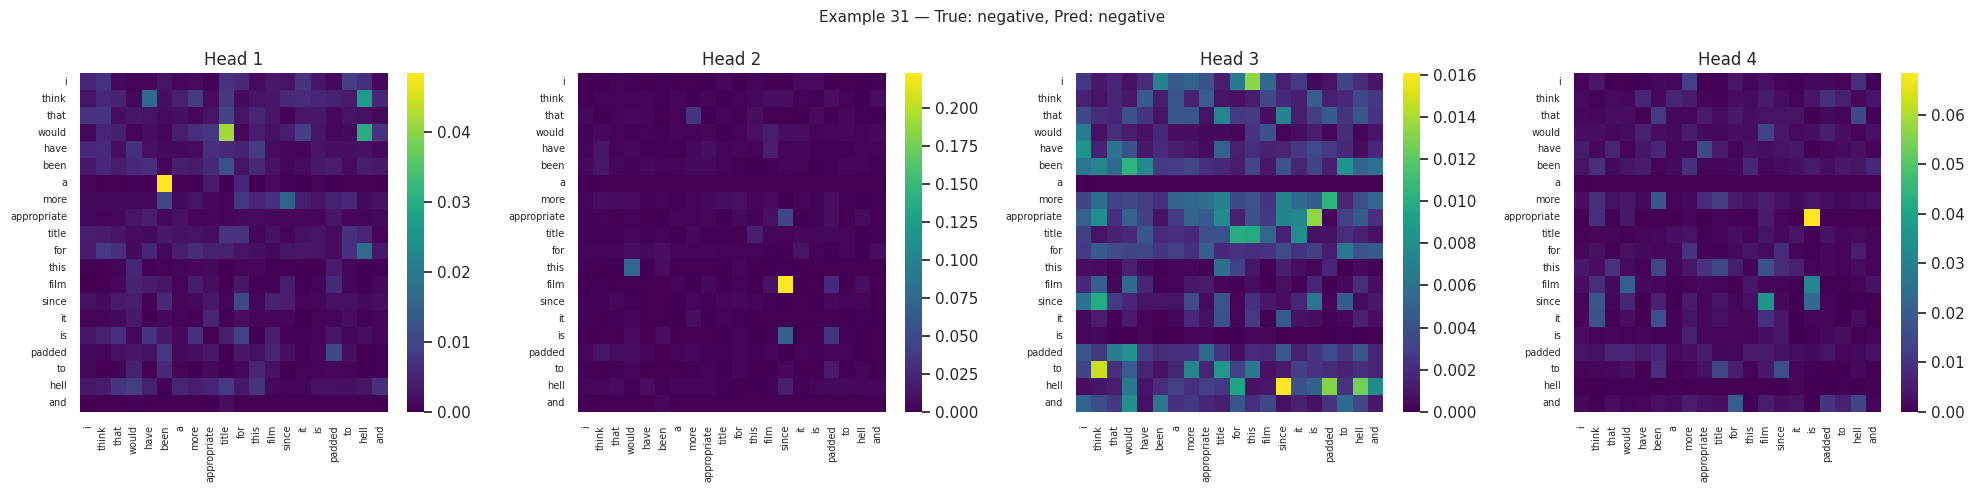

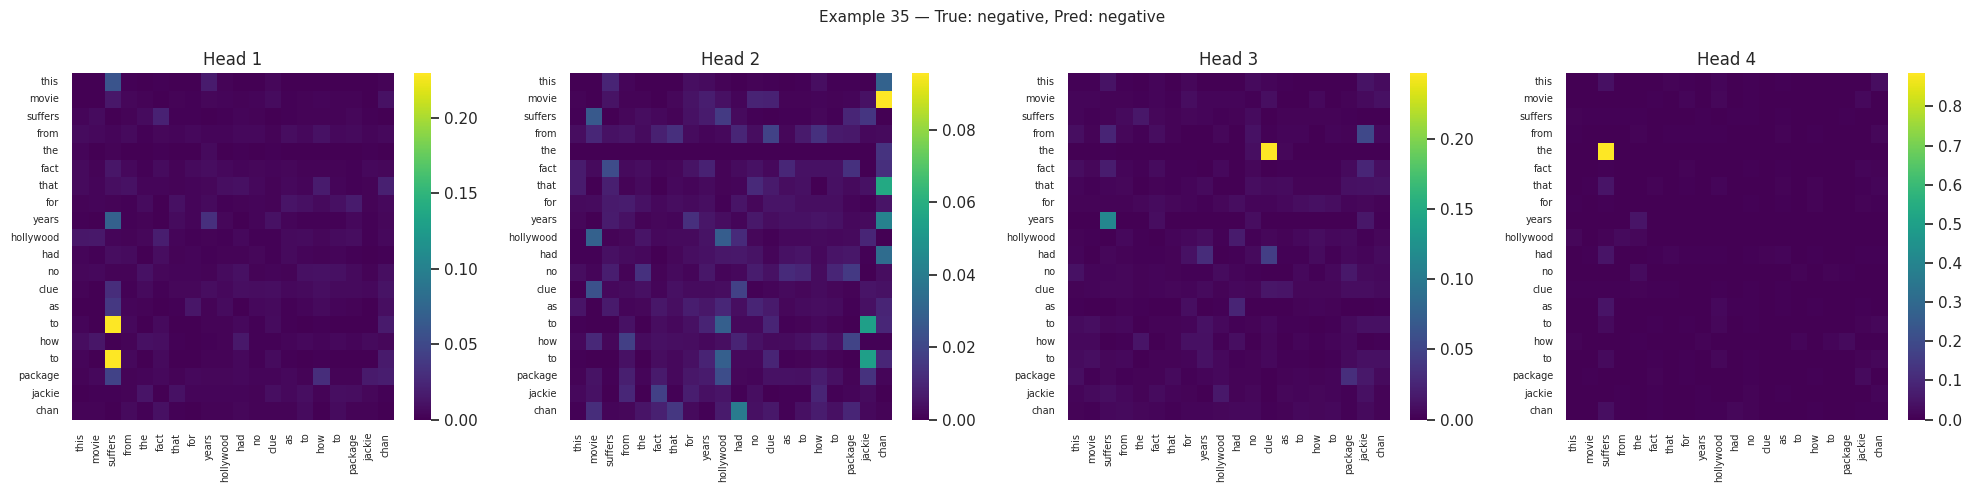

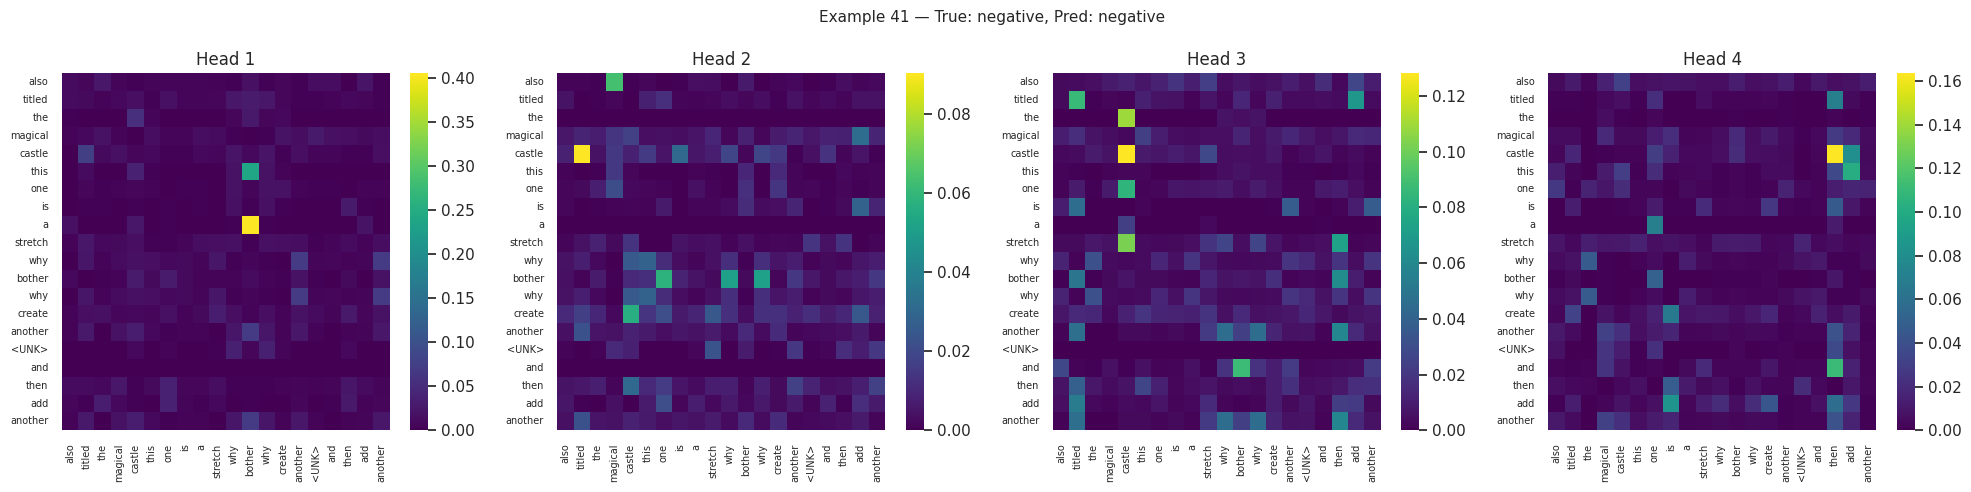

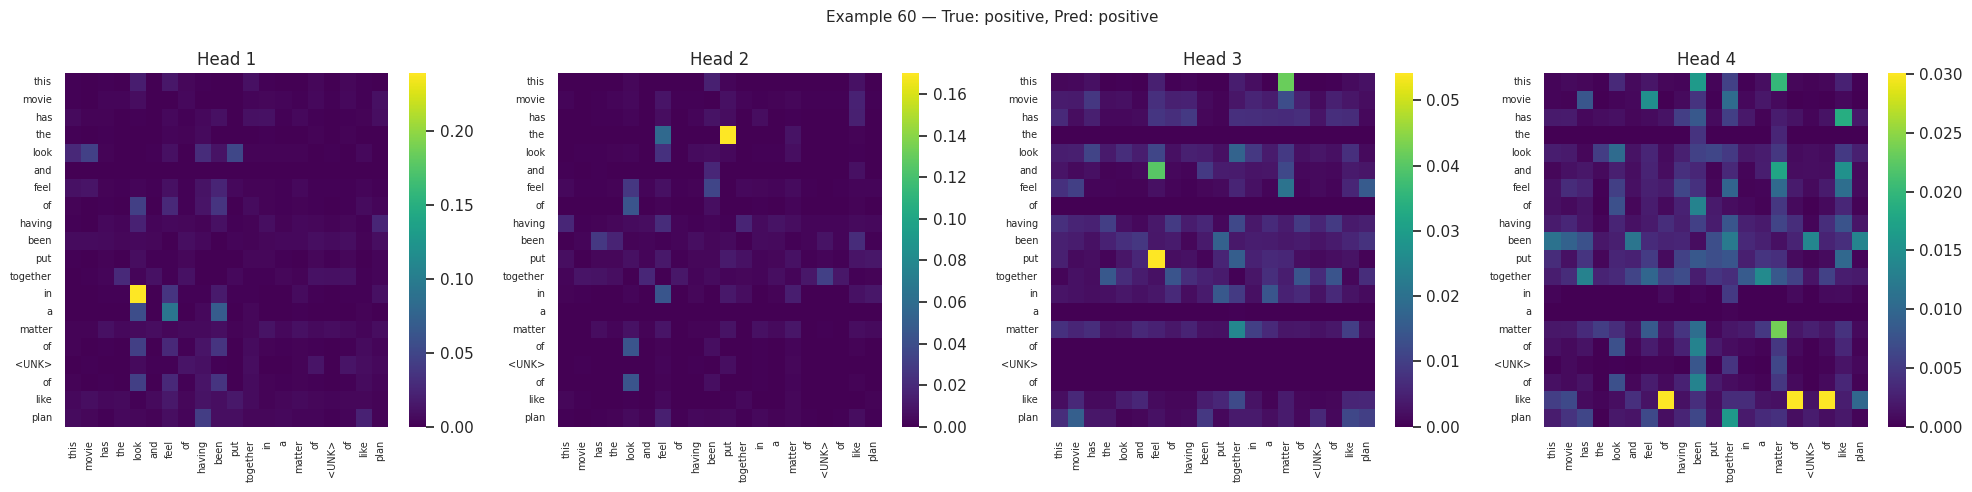

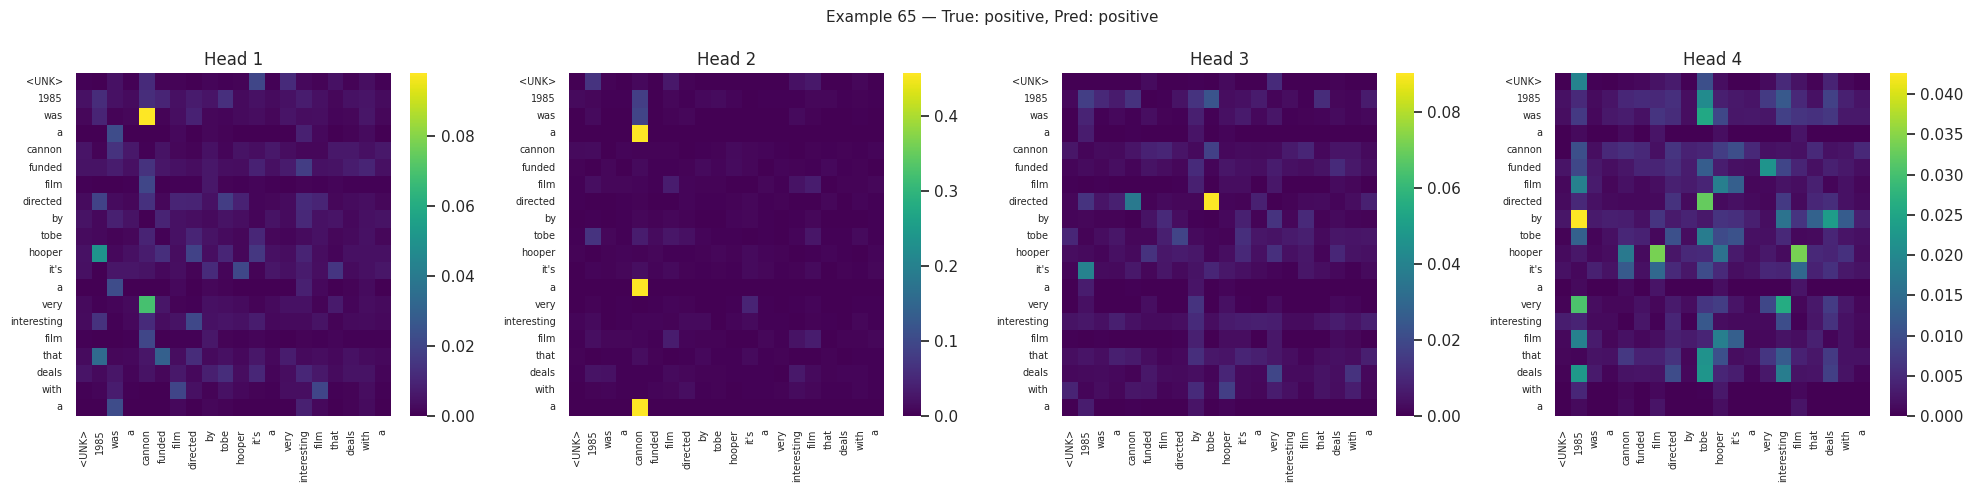

In [59]:
# ANSWER
# For each example, plot a heatmap for each attention head.
#   Use seaborn's heatmap with tokens on both axes.
#   Each head should be a separate subplot.

def plot_attention_heatmaps(tokens, weights, title_prefix="", num_heads_to_show=4, max_display=20):
    """Plot per-head attention heatmaps.

    Args:
        tokens: List of token strings.
        weights: Attention weights, shape (num_heads, seq_len, seq_len).
        title_prefix: Prefix for the plot title.
        num_heads_to_show: Number of heads to display.
    """
    num_heads = min(num_heads_to_show, weights.shape[0])
    seq_len = min(max_display, len(tokens))
    display_tokens = tokens[:seq_len]

    fig, axes = plt.subplots(1, num_heads, figsize=(5 * num_heads, 5))
    if num_heads == 1:
        axes = [axes]

    for head_idx, ax in enumerate(axes):
        head_weights = weights[head_idx][:seq_len, :seq_len]
        sns.heatmap(
            head_weights,
            xticklabels=display_tokens,
            yticklabels=display_tokens,
            ax=ax,
            cmap="viridis",
            vmin=0, vmax=head_weights.max(),
            cbar=True,
        )
        ax.set_title(f"Head {head_idx + 1}")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7)

    fig.suptitle(title_prefix, fontsize=11)
    plt.tight_layout()
    plt.show()


# Plot for each example
sentiment_map = {0: "negative", 1: "positive"}
for ex in examples:
    title = (f"Example {ex['idx']} — "
             f"True: {sentiment_map.get(ex['label'], ex['label'])}, "
             f"Pred: {sentiment_map.get(ex['pred'], ex['pred'])}")
    plot_attention_heatmaps(ex["tokens"], ex["weights"], title_prefix=title)

### Reflective Exercise 4.1

Examine the heatmaps you generated. Answer the following:

1. Which tokens receive the highest attention weights? Do they correspond to sentiment-bearing words (e.g., "great", "terrible", "boring")?
2. Do different heads attend to different things? Can you identify what each head "specializes" in?
3. Does the model always attend to the "right" tokens for the prediction? Can you find cases where high-attention tokens don't intuitively explain the sentiment?
4. Based on your observations, do you think attention weights are reliable explanations of model decisions? Why or why not?

**Answer:**<br>
<br>
1.
<br>
The tokens that received the highest attention weights seem to be the ones that bear sentiment (this is particularly evident in the last example).
<br>
2.
<br>
It is kind of difficult to tell, but in the last example, the second head captures the subject/person saying they love something while the third head specializes in identifying 80's, kid, and rainbow (maybe a nostalgic factor).
<br>
3.
<br>
No, they do not always attend to the "right" token as seen in the first few examples. The attention weights seem to be highest for tokens like "I", "50", "the", etc.
<br>
4.
<br>
They can provide a bit of insight to see what the model is basing a lot of its inference on, but it does not provide a complete picture as to why the model thought decided to choose that token to base its decision on. It tells us where the model looked but not why it looked there.
<br>

## Section 5: Full Comparison Table — BOE vs. TextCNN vs. RNN/LSTM vs. Attention

We've now trained enough NLP architectures across the course to build a definitive comparison. In this section, you'll assemble a table spanning hw08, hw10, and hw11.

## Section 5: RNN Family Sweep — Fair Architecture Comparison

The `BagOfEmbeddings` and `AttentionClassifier` you trained in Section 2 share a carefully
matched configuration: `embedding_dim=128`, `hidden_units=[64]`, `dropout=[0.2]`,
`learning_rate=1e-3`, `batch_size=64`, trained on the same IMDB samples loaded in Step 2.2.
The hw10 RNN experiments used different dataset sizes and training settings — making a
direct cross-notebook comparison unreliable.

To establish a genuine apples-to-apples comparison, you will run a **6-run W&B grid sweep**
that re-trains the full RNN family under those identical conditions, varying only the two
architecture axes:

| `rnn_type` | `bidirectional` |
|------------|-----------------|
| `"rnn"`    | `False`         |
| `"rnn"`    | `True`          |
| `"lstm"`   | `False`         |
| `"lstm"`   | `True`          |
| `"gru"`    | `False`         |
| `"gru"`    | `True`          |

After the sweep finishes, you will pull the results from the W&B API and build a unified
comparison table alongside the BOE and Attention numbers from Section 2.

In [60]:
show_todo("Build the full cross-course architecture comparison table")

In [65]:
# ANSWER
from lantern.sweep import make_train_sweep, print_sweep_info, terminate_sweep

project_sec5 = "csci357-hw11-lab5"

# Adjust training mode parameters to suit your computational resources and patience!
if RUN_TRAINING_MODE == RunTrainingMode.FULL:
    sweep_epochs = num_epochs_text   # 10 — same as Section 2
    sweep_count = 6                  # full 3×2 grid
elif RUN_TRAINING_MODE == RunTrainingMode.QUICK:
    sweep_epochs = num_epochs_text   # 6
    sweep_count = 6
else:
    sweep_epochs = 0
    sweep_count = 0

# Providing a complete sweep config as a starting point
rnn_family_sweep_config = {
    "method": "grid",
    "metric": {
        "name": "val_accuracy",
        "goal": "maximize",
    },
    "parameters": {
        # Fixed — mirrors the Section 2 configs exactly for a controlled comparison
        "model_type":              {"value": "textrnn"},
        "vocab_size":              {"value": len(imdb_vocab)},
        "embedding_dim":           {"value": 128},
        "padding_idx":             {"value": 0},
        "freeze_embeddings":       {"value": False},
        "rnn_hidden_size":         {"value": 128},
        "rnn_num_layers":          {"value": 1},
        "hidden_units":            {"value": [64]},
        "dropout":                 {"value": [0.2]},
        "trainer_batch_size":      {"value": 64},
        "evaluator_batch_size":    {"value": 256},
        "learning_rate":           {"value": 1e-3},
        "weight_decay":            {"value": 1e-5},
        "num_epochs":              {"value": sweep_epochs},
        "early_stopping_patience": {"value": 5},
        "max_seq_len":             {"value": TEXT_MAX_SEQ_LEN},
        # Swept parameters — 3 rnn_type × 2 bidirectional = 6 runs
        "rnn_type":      {"values": ["rnn", "lstm", "gru"]},
        "bidirectional": {"values": [False, True]},
    },
}
# Create your sweep function
rnn_sweep_fn = make_train_sweep(
    wandb_project_name=project_sec5,
    wandb_name_prefix=user_initials,
    datasets=(imdb_train_ds, imdb_test_ds),
    device=accel_device,
    input_spec=0,
    num_outputs=2,
    metrics_config_param=MetricsConfig(task="multiclass", names=["accuracy"]),
    text_collate_fn=text_collate_fn
)

sweep_id_sec5 = None
if DO_WANDB_LOGGING and sweep_count > 0:
    sweep_id_sec5 = wandb.sweep(
        sweep=rnn_family_sweep_config,
        project=project_sec5,
    )
    print("=" * 60)
    print(f"Sweep ID: {sweep_id_sec5}")
    print_sweep_info(sweep_id_sec5)
    wandb.agent(sweep_id=sweep_id_sec5, function=rnn_sweep_fn, count=sweep_count)
    print("\n" + "=" * 60)
    print("Sweep complete! All 6 runs finished.")
    print("=" * 60)
    print_sweep_info(sweep_id_sec5)
    terminate_sweep(sweep_id_sec5)

Create sweep with ID: jban8it4
Sweep URL: https://wandb.ai/cb073-bucknell-university/csci357-hw11-lab5/sweeps/jban8it4
Sweep ID: jban8it4
Sweep jban8it4 has 0 runs
Sweep jban8it4 expected 6 runs
Sweep jban8it4 current state is: PENDING


wandb: Agent Starting Run: 8lqndc0z with config:
wandb: 	bidirectional: False
wandb: 	dropout: [0.2]
wandb: 	early_stopping_patience: 5
wandb: 	embedding_dim: 128
wandb: 	evaluator_batch_size: 256
wandb: 	freeze_embeddings: False
wandb: 	hidden_units: [64]
wandb: 	learning_rate: 0.001
wandb: 	max_seq_len: 512
wandb: 	model_type: textrnn
wandb: 	num_epochs: 10
wandb: 	padding_idx: 0
wandb: 	rnn_hidden_size: 128
wandb: 	rnn_num_layers: 1
wandb: 	rnn_type: rnn
wandb: 	trainer_batch_size: 64
wandb: 	vocab_size: 25002
wandb: 	weight_decay: 1e-05
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


wandb.config: {'bidirectional': False, 'dropout': [0.2], 'early_stopping_patience': 5, 'embedding_dim': 128, 'evaluator_batch_size': 256, 'freeze_embeddings': False, 'hidden_units': [64], 'learning_rate': 0.001, 'max_seq_len': 512, 'model_type': 'textrnn', 'num_epochs': 10, 'padding_idx': 0, 'rnn_hidden_size': 128, 'rnn_num_layers': 1, 'rnn_type': 'rnn', 'trainer_batch_size': 64, 'vocab_size': 25002, 'weight_decay': 1e-05}
Run name set to: CMB_textrnn_rnn_bs64_lr0.00100_hs128_L1_bi0_wd0.00001
Epoch 0:
Train Accuracy=58.87%  Val Accuracy=56.49%
--> New best checkpoint saved: ./checkpoints/csci357-hw11-lab5-best.pt
--> Also saving as last checkpoint: ./checkpoints/csci357-hw11-lab5-last.pt
Epoch 1:
Train Accuracy=63.88%  Val Accuracy=67.79%
--> New best checkpoint saved: ./checkpoints/csci357-hw11-lab5-best.pt
--> Also saving as last checkpoint: ./checkpoints/csci357-hw11-lab5-last.pt
Epoch 2:
Train Accuracy=64.71%  Val Accuracy=68.11%
Epoch 3:
Train Accuracy=68.70%  Val Accuracy=66.03%


epoch,▁▂▃▃▄▅▆▆▇█
train_accuracy,▁▂▂▃▄▆▆▇▇█
val_accuracy,▁▅▅▄▇▂█▆▆▇
epoch,9
train_accuracy,0.90677
val_accuracy,0.74207


Run complete! val_accuracy: 74.21%


...

Run complete! val_accuracy: 83.65%


wandb: Agent Starting Run: lwf5qsan with config:
wandb: 	bidirectional: True
wandb: 	dropout: [0.2]
wandb: 	early_stopping_patience: 5
wandb: 	embedding_dim: 128
wandb: 	evaluator_batch_size: 256
wandb: 	freeze_embeddings: False
wandb: 	hidden_units: [64]
wandb: 	learning_rate: 0.001
wandb: 	max_seq_len: 512
wandb: 	model_type: textrnn
wandb: 	num_epochs: 10
wandb: 	padding_idx: 0
wandb: 	rnn_hidden_size: 128
wandb: 	rnn_num_layers: 1
wandb: 	rnn_type: gru
wandb: 	trainer_batch_size: 64
wandb: 	vocab_size: 25002
wandb: 	weight_decay: 1e-05
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


wandb.config: {'bidirectional': True, 'dropout': [0.2], 'early_stopping_patience': 5, 'embedding_dim': 128, 'evaluator_batch_size': 256, 'freeze_embeddings': False, 'hidden_units': [64], 'learning_rate': 0.001, 'max_seq_len': 512, 'model_type': 'textrnn', 'num_epochs': 10, 'padding_idx': 0, 'rnn_hidden_size': 128, 'rnn_num_layers': 1, 'rnn_type': 'gru', 'trainer_batch_size': 64, 'vocab_size': 25002, 'weight_decay': 1e-05}
Run name set to: CMB_textrnn_gru_bs64_lr0.00100_hs128_L1_bi1_wd0.00001
Epoch 0:
Train Accuracy=64.55%  Val Accuracy=67.55%
--> New best checkpoint saved: ./checkpoints/csci357-hw11-lab5-best.pt
--> Also saving as last checkpoint: ./checkpoints/csci357-hw11-lab5-last.pt
Epoch 1:
Train Accuracy=77.80%  Val Accuracy=77.28%
--> New best checkpoint saved: ./checkpoints/csci357-hw11-lab5-best.pt
--> Also saving as last checkpoint: ./checkpoints/csci357-hw11-lab5-last.pt
Epoch 2:
Train Accuracy=84.87%  Val Accuracy=83.29%
--> New best checkpoint saved: ./checkpoints/csci357-

epoch,▁▂▃▄▅▆▇█
train_accuracy,▁▄▅▆▇███
val_accuracy,▁▅▇▇██▇█
epoch,7
train_accuracy,0.98907
val_accuracy,0.84386


Run complete! val_accuracy: 84.39%

Sweep complete! All 6 runs finished.
Sweep jban8it4 has 6 runs
Sweep jban8it4 expected 6 runs
Sweep jban8it4 current state is: RUNNING
Stopping sweep cb073-bucknell-university/csci357-hw11-lab5/jban8it4
Sweep cb073-bucknell-university/csci357-hw11-lab5/jban8it4 stopped successfully


In [70]:
import json
# ANSWER
# Pull all sweep runs from the W&B API, then combine with the Section 2 BOE and
# Attention results (if you did not run the optional step above) 
# into a single comparison DataFrame.

sweep_rows = []
if DO_WANDB_LOGGING and sweep_id_sec5 is not None:
    api = wandb.Api()
    api.flush()
    # Force a refresh to ensure we have the latest data
    runs = api.runs(f"{project_sec5}", filters={"sweep": sweep_id_sec5})
    print(f"Retrieved {len(runs)} runs from sweep {sweep_id_sec5}")

    for run in runs:                                                                                                                                                                                                                                                                                                                                                                                                                                                                            
        val_acc = run.summary.get("val_accuracy", float("nan"))                                                                                                                             
        total_params = run.summary.get("total_params", float("nan"))
        rnn_type  = run.config.get("rnn_type", "?")                                                                                                                                                
        bidir = run.config.get("bidirectional", False) 
                                                                                                                                                                                            
        label = f"{'Bi' if bidir else ''}{rnn_type.upper()} (hw11-sweep)"                                                                                                                     
        sweep_rows.append({                                                                                                                                                                 
            "model":        label,                                                                                                                                                            
            "total_params": total_params,                                                                                                                                                     
            "val_accuracy": val_acc,                                                                                                                                                        
        }) 



# Add BOE and Attention baselines from Section 2                                                                                                                                            
total_boe,  _ = boe_model.num_parameters()
total_attn, _ = attn_model.num_parameters()                                                                                                                                                   

static_rows = [                                                                                                                                                                               
    {                                                                                                                                                                                       
        "model":        "BagOfEmbeddings (hw11)",                                                                                                                                           
        "total_params": total_boe,                                                                                                                                                            
        "val_accuracy": boe_results.get("val_accuracy", float("nan")),
    },                                                                                                                                                                                        
    {                                                                                                                                                                                       
        "model":        "AttentionClassifier (hw11)",                                                                                                                                       
        "total_params": total_attn,                                                                                                                                                           
        "val_accuracy": attn_results.get("val_accuracy", float("nan")),
    },                                                                                                                                                                                        
]                                                                                                                                                                                           
                                                                                                                                                                                            
all_rows = static_rows + sweep_rows                                                                                                                                                           
comparison_df = (
    pd.DataFrame(all_rows)                                                                                                                                                                    
    .sort_values("val_accuracy", ascending=False)                                                                                                                                         
    .reset_index(drop=True)                                                                                                                                                                 
)
                                                                                                                                                                                            
display(comparison_df)

Retrieved 6 runs from sweep jban8it4


,model,total_params,val_accuracy
0,GRU (hw11-sweep),NaN,0.863124
1,BagOfEmbeddings (hw11),3208642.0,0.855178
2,AttentionClassifier (hw11),3274690.0,0.845940
3,BiGRU (hw11-sweep),NaN,0.843864
4,BiLSTM (hw11-sweep),NaN,0.836528
5,LSTM (hw11-sweep),NaN,0.802967
6,RNN (hw11-sweep),NaN,0.742068
7,BiRNN (hw11-sweep),NaN,0.717535


### Analysis 5.1

Using the sweep results above along with your findings earlier in the Lab section, 
write a conclusion comparing the RNN family against `BagOfEmbeddings` and `AttentionClassifier`. Address all four of the following:

1. Does adding gating (LSTM/GRU) consistently help over a vanilla RNN under these controlled conditions?
2. Does bidirectionality provide a consistent improvement, or does it depend on the
   base architecture?
3. How does the best RNN-family model compare to `BagOfEmbeddings` and `AttentionClassifier`?
4. What does this controlled comparison tell you about architectural complexity vs.
   accuracy on binary sentiment classification?
5. Comment on limits and biases that may exist in this simplistic setup

**ANSWER**
1. Yes, adding gating helps because earlier tokens are not forgotten/diminished when processing later tokens.

<br>
2. No, it depends on the base architecture. It did not improve for GRU but it did for other ones.

<br>
3. They perform comparably (but slightly worse) than the BOE or AttentionClassifier.

<br>
4. It indicates that architectural complexity does not always mean better accuracy. It depends on the nature of the task and could rely on factors like inductive bias.

<br>
5. Attention is probably overkill in this scenario and recurrent structure is not providing much value as taking the mean pooled sentiment of all tokens in a review is good enough for the task.

In [ ]:
show_section("Challenges")

---
# Challenges

This week's challenges explore attention from multiple angles: competitive model tuning under parameter constraints, attention on non-text data (financial time series), positional encoding as a bridge to transformers, harder NLP datasets, and a genuine research question about attention interpretability.

## Challenge 1: Attention Classifier W&B Competition — Maximum Accuracy, Minimum Parameters

Maximize validation accuracy on IMDB using only `AttentionClassifier` under a strict **3 million total parameter** budget (including the embedding table). Submit results to a shared W&B project `csci357-hw11-competition`.

### Your task:

1. The parameter budget is 3,000,000 **total** parameters. This includes the embedding table ($\text{vocab\_size} \times \text{embed\_dim}$), the attention layer ($4 \times \text{embed\_dim}^2 + \text{biases}$), and the classifier head.
2. Decide on a strategy for fitting within the budget. Key trade-offs:
   - **Reducing `vocab_size`** (e.g., to 15,000) shrinks the embedding table significantly but loses rare words.
   - **Reducing `embedding_dim`** shrinks both the embedding table and the attention layer but reduces model capacity.
   - **Increasing `num_heads`** does not change parameters but changes how capacity is partitioned.
   - **Adding hidden layers** in the FC head adds parameters but may improve classification.
3. Log all runs to `csci357-hw11-competition` with `entity` set to the class entity.
4. Write a short explanation (1 paragraph) of your configuration choices and the trade-offs you considered.

**Success criteria:** Top-3 validation accuracy on the class leaderboard; a written explanation that demonstrates understanding of the parameter budget.

In [ ]:
show_todo("Challenge 1: Maximize IMDB accuracy under 3M parameter budget")

In [71]:
# ANSWER
# Design an AttentionClassifier configuration that maximizes accuracy
#   while staying under 3M total parameters.
#
# Strategy:
#   vocab_size educes embedding table
#   embedding_dim keeps attention capacity high
#   num_heads=4 is a good default partition
#   hidden_units=[???.???] adds a deeper head

# Rebuild dataset with reduced vocab
def random_sample_fn(ds, n_samples):
    """Randomly sample n_samples examples from a HuggingFace dataset."""
    indices = random.sample(range(len(ds)), n_samples)
    return ds.select(indices)

imdb_train_ds, imdb_test_ds, imdb_vocab = get_hf_text_dataset(
    "imdb",
    max_vocab_size=20000,
    train_subset_fn=lambda ds: random_sample_fn(ds, num_samples),
    test_subset_fn=lambda ds: random_sample_fn(ds, num_samples),
)

# Set up ModelConfig
c1_config = ModelConfig(
    model_type=ModelType.TEXTATTN,
    embedding_dim=128, 
    hidden_units=[128, 256, 64],
    dropout=[0.2, 0.3, 0.1],
    num_heads=4,
    vocab_size=len(imdb_vocab),
    max_seq_len=512,
)

# build the model
c1_model = build_model(1, 2, c1_config)

# check the parameter budget!
total_c1, trainable_c1 = c1_model.num_parameters()
print(f"Challenge 1 model: total={total_c1:,}, trainable={trainable_c1:,}")
assert total_c1 <= 3_000_000, f"Over budget! {total_c1:,} > 3,000,000"
print("Within 3M parameter budget!")

Challenge 1 model: total=2,692,418, trainable=2,692,418
Within 3M parameter budget!


In [ ]:
# ANSWER
# Set epochs and train.
c1_epochs = 0
if RUN_TRAINING_MODE == RunTrainingMode.FULL:
    c1_epochs = 15
elif RUN_TRAINING_MODE == RunTrainingMode.QUICK:
    c1_epochs = 7

# Set up TrainerConfig
c1_t_cfg = TrainerConfig(
    trainer_batch_size=128,
    evaluator_batch_size=256,
    device=accel_device,
    num_epochs=c1_epochs,
)

# Set up your text collate function if you altered max_seq_len. For example:
my_collate_fn = partial(text_collate_fn, max_seq_len=c1_config.max_seq_len, padding_value=c1_config.padding_idx)

c1_train_loader, c1_test_loader, _ = get_dataloaders(
    train_dataset=imdb_train_ds, 
    eval_dataset=imdb_test_ds,
    train_batch_size=128,
    eval_batch_size=256,
    collate_fn=my_collate_fn,
)


In [ ]:
# ANSWER
c1_run = None
if DO_WANDB_LOGGING and c1_epochs > 0:
    c1_run = wandb.init(
        project="csci357-hw11-chal01",
        entity=entity,
        name=f"{user_initials}-c1-attn-{total_c1 // 1000}k",
        config={
            "model_type": "text_attn",
            "vocab_size": 20000,
            "embedding_dim": 128,
            "num_heads": 4,
            "hidden_units": [128, 256, 64],
            "total_params": total_c1,
            "num_epochs": c1_epochs,
        },
    )

# train
with Trainer(
    model=c1_model,
    optimizer=make_optimizer(c1_model.parameters(), c1_t_cfg),
    criterion=nn.CrossEntropyLoss(),
    config=c1_t_cfg,
    metrics_config=MetricsConfig(task="multiclass", names=["accuracy", "loss"]),
    run=c1_run,
) as trainer:
    c1_results = trainer.fit(c1_train_loader, c1_test_loader)


if c1_run is not None:
    c1_run.finish()

print(f"\nChallenge 1 Results: {c1_results}")
print(f"Total parameters: {total_c1:,}")

Epoch 0:
Train Accuracy=70.17%  Val Accuracy=80.66%
Train Loss=0.5650  Val Loss=0.4198
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Accuracy=83.87%  Val Accuracy=83.95%
Train Loss=0.3707  Val Loss=0.3595
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Accuracy=87.98%  Val Accuracy=84.78%
Train Loss=0.2896  Val Loss=0.3496
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 3:
Train Accuracy=91.09%  Val Accuracy=85.34%
Train Loss=0.2287  Val Loss=0.3428
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 4:
Train Accuracy=93.57%  Val Accuracy=85.17%
Train Loss=0.1741  Val Loss=0.3846
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 5:
Train Accuracy=95.49%  Val Accuracy=85.19%
Train Loss=0.1237  Val L

epoch,▁▂▃▄▅▅▆▇█
train_accuracy,▁▄▅▆▇▇███
train_loss,█▅▄▄▃▂▂▁▁
val_accuracy,▁▆▇████▇▇
val_loss,▂▁▁▁▂▃▄█▇
epoch,8
train_accuracy,0.98452
train_loss,0.04055
val_accuracy,0.84561
val_loss,0.71167



Challenge 1 Results: {'num_epochs': 9, 'train_accuracy': 0.9845226407051086, 'val_accuracy': 0.8456081748008728, 'train_loss': 0.040552309358119966, 'val_loss': 0.7116654652277629}
Total parameters: 2,692,418


### Challenge 1 Written Explanation

**Answer:**
<br>
Here, I set the embedding layer parameters as 20,000 for the vocab size and 128 for the embedding dimension, giving me 2,560,000 parameters. The MHA then had 4 heads each with 4 matrices (Q, K, V, O) with shape (128, 32), which is equivalent to having 4 x (128, 128) matrices, we have 66,048 parameters. Then the classifier head has (128 x 256 + 256) + (256 x 128 + 128) + (128 x 64 + 64) + (64 x 2 + 2) = 74,306 parameters. Adding all these together, we have 2,692,418 total parameters.
<br>

## Challenge 2: Attention on Financial Time Series (yfinance)

Apply a self-attention sequence classifier to a financial time series prediction task. Download 3–5 years of daily price and volume data for **Johnson & Johnson (JNJ)** via `yfinance`. Cast it as a binary classification task: will the log return tomorrow be positive (price up) or negative (price down)?

**Why JNJ?** In hw10, you worked with NVDA (tech sector). JNJ is a large-cap healthcare/consumer stock with very different price dynamics — lower volatility, more stable trends, and less speculative trading. This diversifies your experience across market sectors.

### Feature Engineering (required)

**Do not feed raw closing prices into the model.** Raw prices are non-stationary — they trend over years — and contain no generalizable information across time periods. Instead:

1. Compute daily **log returns**: $r_t = \ln(P_t / P_{t-1})$. This converts to a stationary, zero-centered series.
2. Optionally add: (a) **30-day rolling volatility** (rolling std of log returns, normalized), and/or (b) **log trading volume** (normalized). You can also add your own features of interest.
3. Use a sliding window of 30 days of features as the input sequence (shape: `(30, num_features)`). The label is the sign of the next day's log return.

### Architecture

We'll focus on a classifier that predicts whether the return is positive or negative for tomorrow. Project each timestep's feature vector to `embed_dim` via a linear layer, apply `nn.MultiheadAttention`, mean pool, FC head with 2 outputs (up/down).

### Your task:

1. Download JNJ data using `yfinance` (at least 3 years)
2. Compute log returns and at least two additional features.
3. Build a sliding-window dataset
4. Implement a `TimeSeriesAttentionClassifier` (does not need to be in the engine)
5. Train and evaluate; compare vs. a naive baseline (predict "up" every day)
6. Report accuracy, F1, and confusion matrix on held-out test data
7. Visualize attention weights over the 30-day window for 3 test predictions

In [ ]:
show_todo("Challenge 2: Download JNJ financial data and build attention classifier")

[*********************100%***********************]  1 of 1 completed

Downloaded 1258 trading days
Price            Close        High         Low        Open   Volume
Ticker             JNJ         JNJ         JNJ         JNJ      JNJ
Date                                                               
2020-01-02  122.638237  122.680248  121.890495  122.554216  5777000
2020-01-03  121.218338  122.134110  120.142934  120.563014  5752400
2020-01-06  121.067108  121.151116  120.016908  120.983087  7731300
2020-01-07  121.806473  122.201349  118.781902  120.991516  7382900
2020-01-08  121.789673  122.646627  120.731062  121.714049  6605800


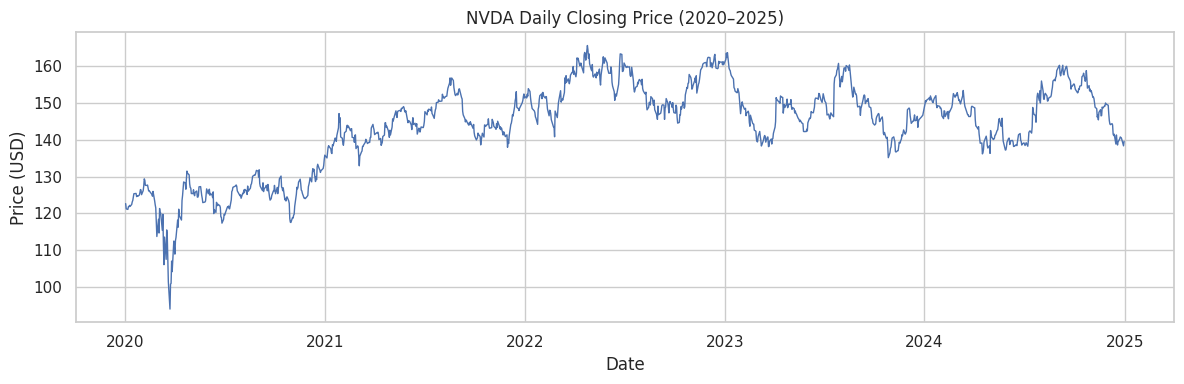

In [ ]:
# ANSWER
# Download JNJ stock data using yfinance.
import yfinance as yf

# Download ~5 years of daily data for JNJ (healthcare sector)
jnj = yf.download("JNJ", start="2020-01-01", end="2025-01-01", auto_adjust=True)
jnj_close = jnj["Close"].squeeze().dropna()

# yfinance may return multi-level columns; flatten if needed

print(f"Downloaded {len(jnj)} trading days")
print(jnj.head())

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(jnj_close.index, jnj_close.values, linewidth=1.0)
ax.set_title("JNJ Daily Closing Price (2020–2025)")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
plt.tight_layout()
plt.show()

In [ ]:
# ANSWER
# Compute log returns and rolling volatility features.
#   log_return = ln(Close_t / Close_{t-1}) — stationary, zero-centered
#   rolling_vol = 30-day rolling std of log returns — captures regime changes
#   log_volume = log(Volume) normalized — captures trading activity

# Log returns: stationary price change signal
close_vals = jnj_close.values.astype(np.float32)
jnj_log_returns = np.log(close_vals[1:] / close_vals[:-1])


# 30-day rolling volatility of log returns
rolling_volatility = []
for i in range(len(jnj_log_returns)-29):
    rolling_volatility.append(np.std(jnj_log_returns[i:i+30]))

# Trim log returns to match rolling_volatility length
# Drop the first 29 log-return entries (insufficient history for a full window)
jnj_log_returns_trimmed = jnj_log_returns[29:]   # same length as rolling_volatility

# Align the raw DataFrame to the same date range
# Original jnj_close has N prices; log returns drop index 0; trimming drops 29 more
# So the aligned dates start at position 30 of the original jnj_close index
aligned_dates = jnj_close.index[30:]             # N - 30 dates
jnj_aligned = jnj.loc[aligned_dates].copy()

# Log volume (normalized)
log_volume = np.log(jnj_aligned["Volume"].values.astype(np.float32)).squeeze()

feature_cols = ["log_return", "rolling_vol", "log_volume"]
jnj_features = pd.DataFrame({
    "log_return": jnj_log_returns_trimmed,
    "rolling_vol": rolling_volatility,
    "log_volume": log_volume,
}, index=aligned_dates)

# Drop NaN rows from rolling calculations
jnj = jnj_aligned.copy()
jnj[feature_cols] = jnj_features[feature_cols]
jnj = jnj.dropna()

# Normalize features to zero mean, unit variance (fit on entire series first,
# then we'll do proper train-only fitting below)
from sklearn.preprocessing import StandardScaler

scaler= StandardScaler()
jnj[feature_cols] = scaler.fit_transform(jnj[feature_cols])

print(jnj[feature_cols].describe())

Price     log_return  rolling_vol    log_volume
Ticker                                         
count   1.228000e+03  1228.000000  1.228000e+03
mean    7.766078e-09     0.000000 -3.106431e-09
std     1.000407e+00     1.000407  1.000408e+00
min    -6.090206e+00    -0.902166 -2.984592e+00
25%    -4.678946e-01    -0.480263 -5.890276e-01
50%     6.175954e-04    -0.191240 -1.327638e-01
75%     4.676254e-01     0.154455  3.915320e-01
max     6.169713e+00     6.157726  7.389939e+00


In [ ]:
# Build sliding window dataset.
#   window_size=30 (30 trading days of features as input)
#   label = 1 if next day's log return > 0 (price up), else 0

WINDOW_SIZE = 30



# ── Create windows and labels ──
X_windows = []
y_labels = []

for i in range(len(jnj) - 30):
    X_windows.append(jnj[feature_cols].iloc[i:i+30].values)
    y_labels.append(int(jnj["log_return"].iloc[i+30] > 0))


# Convert to numpy arrays
X_windows = np.array(X_windows, dtype=np.float32)   # (N, 30, 3)
y_labels   = np.array(y_labels,  dtype=np.int64)     # (N,)

print(f"Total windows: {X_windows.shape[0]}")
print(f"Window shape: {X_windows.shape[1:]}")  # (30, 3)
print(f"Label distribution: up={y_labels.sum()}, down={len(y_labels) - y_labels.sum()}")

Total windows: 1198
Window shape: (30, 3)
Label distribution: up=603, down=595


In [ ]:
# ANSWER
# Temporal train/val/test split (80/10/10 — no shuffling for time series).
#   Fit StandardScaler on train only, then transform val and test.
n = len(X_windows)
train_end = int(0.8 * n)
val_end = int(0.9 * n)

X_train, y_train = X_windows[:train_end], y_labels[:train_end]
X_val, y_val = X_windows[train_end:val_end], y_labels[train_end:val_end]
X_test, y_test = X_windows[val_end:], y_labels[val_end:]

# Fit scaler on train data only - reshape (N, 30, 3) → (-1, 3) for sklearn
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, 3)).reshape(-1, 30, 3)


# Transform each split
X_val = scaler.transform(X_val.reshape(-1, 3)).reshape(-1, 30, 3)
X_test = scaler.transform(X_test.reshape(-1, 3)).reshape(-1, 30, 3)


# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)


y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

from torch.utils.data import TensorDataset, DataLoader

train_ds = TensorDataset(X_train, y_train)
val_ds = TensorDataset(X_val, y_val)
test_ds = TensorDataset(X_test, y_test)

train_dl = DataLoader(train_ds, batch_size=128, shuffle=False)  # no shuffle: time series
val_dl   = DataLoader(val_ds,   batch_size=256, shuffle=False)
test_dl  = DataLoader(test_ds,  batch_size=256, shuffle=False)


print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

Train: 958, Val: 120, Test: 120


In [ ]:
# ANSWER
# Implement TimeSeriesAttentionClassifier.
#   Architecture: Linear projection -> MultiheadAttention -> mean pool -> FC head
#   This model is defined in the notebook (not in the engine).

class TimeSeriesAttentionClassifier(nn.Module):
    """Self-attention classifier for multivariate time series.

    Architecture:
        Linear(num_features -> embed_dim) -> MultiheadAttention -> Mean Pool -> FC Head

    Args:
        num_features (int): Number of input features per timestep.
        embed_dim (int): Dimension to project features into before attention.
        num_heads (int): Number of attention heads.
        num_outputs (int): Number of output classes.
        hidden_dim (int): Hidden layer size in the FC head.
        dropout (float): Dropout rate.
    """
    def __init__(self, num_features, embed_dim=64, num_heads=4,
                 num_outputs=2, hidden_dim=32, dropout=0.2):
        super().__init__()
        
        self.num_outputs = num_outputs
        
        self.linear_proj = nn.Linear(
            in_features=num_features,
            out_features=embed_dim,
        )
        self.mha = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.classifier_head = nn.Sequential(
            nn.Linear(
                in_features=embed_dim,
                out_features=hidden_dim,
            ),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_outputs)
        )


    def forward(self, x):
        """Forward pass.

        Args:
            x: FloatTensor of shape (batch, seq_len, num_features).

        Returns:
            Logit tensor of shape (batch, num_outputs).
        """

        x = self.linear_proj(x)
        x, _ = self.mha(x, x, x)
        x = x.mean(dim=1)
        
        return self.classifier_head(x)


ts_attn_model = TimeSeriesAttentionClassifier(
    num_features=3,      # log_return, rolling_vol, log_volume
    embed_dim=64,
    num_heads=4,
    num_outputs=2,       # binary: up or down
    hidden_dim=32,
    dropout=0.2,
).to(accel_device)

print(ts_attn_model)
total_p = sum(p.numel() for p in ts_attn_model.parameters())
print(f"Total parameters: {total_p:,}")

TimeSeriesAttentionClassifier(
  (linear_proj): Linear(in_features=3, out_features=64, bias=True)
  (mha): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
  )
  (classifier_head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=2, bias=True)
  )
)
Total parameters: 19,042


In [ ]:
# ANSWER
# Train the time series attention classifier.
ts_epochs = 0
if RUN_TRAINING_MODE == RunTrainingMode.FULL:
    ts_epochs = 40
elif RUN_TRAINING_MODE == RunTrainingMode.QUICK:
    ts_epochs = 20

ts_config = TrainerConfig(
    trainer_batch_size=128,
    evaluator_batch_size=256,
    device=accel_device,
    num_epochs=ts_epochs,
    early_stopping_patience=None,
)

with Trainer(
    model=ts_attn_model,
    optimizer=make_optimizer(ts_attn_model.parameters(), ts_config),
    criterion=nn.CrossEntropyLoss(),
    config=ts_config,
    metrics_config=MetricsConfig(task="multiclass", names=["accuracy", "loss"]),
    run=None,
) as trainer:
    results = trainer.fit(train_dl, val_dl)

best_val_acc = results["val_accuracy"]

print(f"\nBest val accuracy: {best_val_acc:.4f}")

Epoch 0:
Train Accuracy=49.88%  Val Accuracy=58.38%
Train Loss=0.6928  Val Loss=0.6911
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Accuracy=49.79%  Val Accuracy=47.03%
Train Loss=0.6918  Val Loss=0.6933
Epoch 2:
Train Accuracy=50.53%  Val Accuracy=50.00%
Train Loss=0.6908  Val Loss=0.6937
Epoch 3:
Train Accuracy=52.75%  Val Accuracy=50.00%
Train Loss=0.6892  Val Loss=0.6933
Epoch 4:
Train Accuracy=51.55%  Val Accuracy=50.00%
Train Loss=0.6924  Val Loss=0.6936
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 5:
Train Accuracy=50.23%  Val Accuracy=50.00%
Train Loss=0.6922  Val Loss=0.6924
Epoch 6:
Train Accuracy=53.08%  Val Accuracy=50.85%
Train Loss=0.6899  Val Loss=0.6920
Epoch 7:
Train Accuracy=52.65%  Val Accuracy=50.00%
Train Loss=0.6888  Val Loss=0.6932
Epoch 8:
Train Accuracy=51.26%  Val Accuracy=50.00%
Train Loss=0.6919  Val Loss=0.6934
Epoch 9:
Train Accuracy=50.66%  Val Accuracy=50.00%
Train Los

Attention model — Test Acc: 0.4917, F1: 0.4913
Naive baseline  — Test Acc: 0.5000, F1: 0.3333


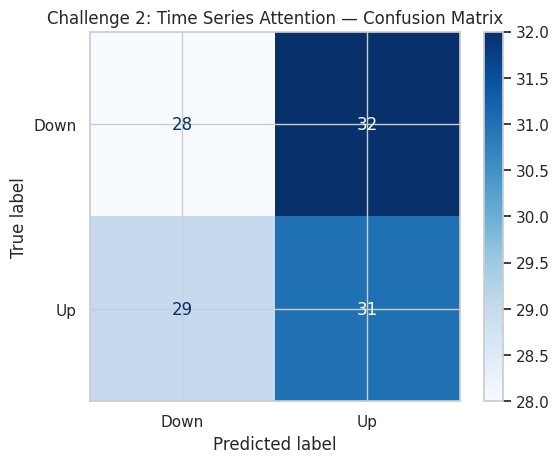

In [ ]:
# ANSWER
# Evaluate on test set. Compute accuracy, F1, confusion matrix.
#   Also compute the naive baseline (predict "up" every day).
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay

ts_attn_model.eval()

n = len(test_ds)
all_preds = []
all_labels = []
for idx in range(n):
    x_test, y_test = test_ds[idx]
    
    with torch.no_grad():
        logits = ts_attn_model(x_test.unsqueeze(0).to(accel_device))
        
    pred = logits.argmax(dim=1).squeeze().cpu()
    all_preds.append(pred)
    all_labels.append(y_test)

all_preds = torch.stack(all_preds)
all_labels = torch.stack(all_labels)

test_acc = (all_preds == all_labels).float().mean().item()
test_f1 = f1_score(all_labels.numpy(), all_preds.numpy(), average="macro")

# Naive baseline: predict "up" (1) every day
naive_preds = [1] * n
naive_acc = (np.array(naive_preds) == all_labels.numpy()).mean()
naive_f1 = f1_score(all_labels.numpy(), naive_preds, average="macro")

print(f"Attention model — Test Acc: {test_acc:.4f}, F1: {test_f1:.4f}")
print(f"Naive baseline  — Test Acc: {naive_acc:.4f}, F1: {naive_f1:.4f}")

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Down", "Up"])
disp.plot(cmap="Blues")
plt.title("Challenge 2: Time Series Attention — Confusion Matrix")
plt.show()

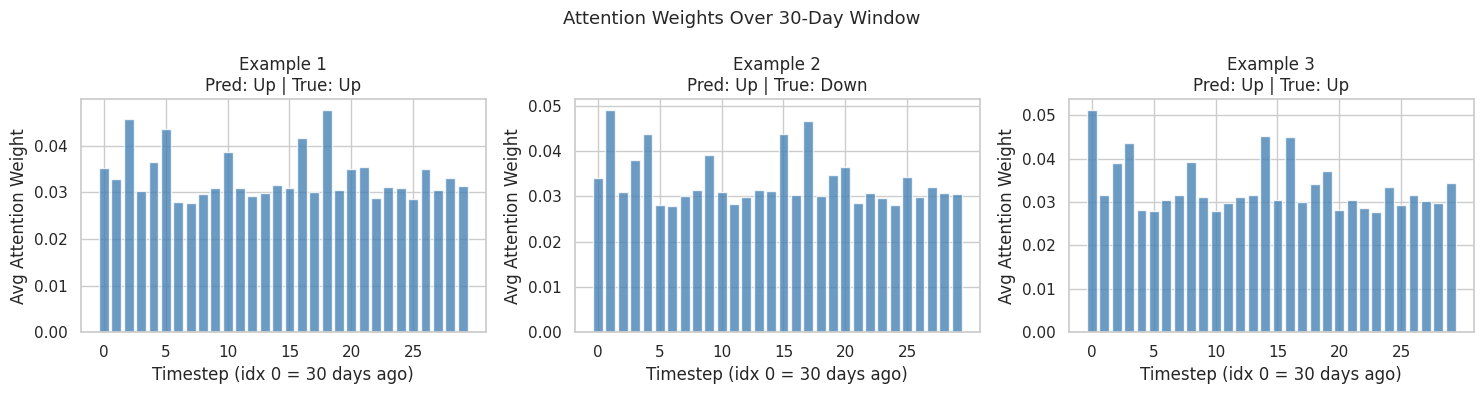

In [ ]:
# ANSWER
# Visualize attention weights for 3 test examples.
#   Show which of the 30 days the model attends to most when predicting up/down.

ts_attn_model.eval()

fig, axes = plt.subplots(1, 3, figsize=(15,4))

for plot_idx in range(3):
    x, y = test_ds[plot_idx]
    x_dev = x.unsqueeze(0).to(accel_device)  # (1, 30, 3)
    
    with torch.no_grad():
        proj = ts_attn_model.linear_proj(x_dev)
        _, attn_weights = ts_attn_model.mha(
            proj, proj, proj,
            need_weights=True,
            average_attn_weights=True
        )
        
    avg_attn = attn_weights.squeeze(0).mean(dim=0).cpu().numpy()
    
    with torch.no_grad():
        logits = ts_attn_model(x_dev)
        
    pred = logits.argmax(dim=1).item()
    label = y.item()
    
    ax = axes[plot_idx]
    ax.bar(range(30), avg_attn, color="steelblue", alpha=0.8)
    ax.set_title(
        f"Example {plot_idx+1}\n"
        f"Pred: {'Up' if pred==1 else 'Down'} | "
        f"True: {'Up' if label==1 else 'Down'}"
    )
    ax.set_xlabel("Timestep (idx 0 = 30 days ago)")
    ax.set_ylabel("Avg Attention Weight")
    ax.set_xticks(range(0, 30, 5))
    
plt.suptitle("Attention Weights Over 30-Day Window", fontsize=13)
plt.tight_layout()
plt.show()

### Challenge 2 Reflection

**Answer:**
<br>
We can see that the model barely learns anything because it is quite hard to predict the stock direction from price/volume features alone. The test accuracy is lower than naive baseline, but it has a higher f1 since the model at least predicts "down" sometimes (the recall for "down" is not 0). This tells me that the efficient market hypothesis is working against me (log returns are close to a random walk) and the feature engineering is probably not relevant for this task. The model is just learning noise.
<br>

## Challenge 3: Positional Encoding Preview (Bridge to Week 12)

Implement a sinusoidal positional encoding layer and add it to the `AttentionClassifier` pipeline. This challenge is an **explicit bridge to next week** — students who complete it will have already built one of the three key components of the transformer encoder.

### Architecture addition

A `PositionalEncoding` module adds position-dependent vectors to the embedded input before attention:

$$\text{PE}(pos, 2i) = \sin\!\left(\frac{pos}{10000^{2i/d}}\right), \qquad \text{PE}(pos, 2i+1) = \cos\!\left(\frac{pos}{10000^{2i/d}}\right)$$

### Your task:

1. Implement `PositionalEncoding` as an `nn.Module`
2. Create an `AttentionClassifierWithPE` that inserts it between embedding and attention
3. Demonstrate that it changes attention weight patterns on at least one example where word order matters (e.g., "The movie is not good" vs. "The movie is good, not boring")
4. Report whether it improves IMDB accuracy

**Why this matters:** IMDB sentiment is largely order-insensitive (bag-of-words works well), so the accuracy improvement may be small. The pedagogical point is understanding *why* position matters for harder tasks.

In [ ]:
show_todo("Challenge 3: Implement PositionalEncoding and add to AttentionClassifier")

In [ ]:
# ANSWER
#  Implement sinusoidal PositionalEncoding module.
#   PE(pos, 2i)   = sin(pos / 10000^(2i/d))
#   PE(pos, 2i+1) = cos(pos / 10000^(2i/d))
#   The encoding is precomputed for max_len positions and stored as a buffer.

import math

class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding from Vaswani et al. (2017).

    Adds a deterministic position-dependent vector to each embedding. The encoding
    is precomputed for up to max_len positions and stored as a non-learnable buffer.

    Args:
        embed_dim (int): Embedding dimension (must match the input).
        max_len (int): Maximum sequence length to precompute encodings for.
        dropout (float): Dropout rate applied after adding positional encoding.
    """
    def __init__(self, embed_dim, max_len=5000, dropout=0.1):
        super().__init__()
        pe = torch.zeros(max_len, embed_dim) # (max_len, embed_dim)
        pos = torch.arange(0, max_len).unsqueeze(1).float() # (max_len, 1)
        
        i = torch.arange(0, embed_dim, 2).float()
        # a^b = exp(b * log(a))
        div_term = torch.exp((-i/embed_dim) * math.log(10000.0))
                
        pe[:, 0::2] = torch.sin(pos * div_term) # even dims: sin
        pe[:, 1::2] = torch.cos(pos * div_term) # odd  dims: cos
        
        self.register_buffer("pos_enc", pe.unsqueeze(0)) # (1, max_len, embed_dim)
                
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        """Add positional encoding to input embeddings.

        Args:
            x: FloatTensor of shape (batch, seq_len, embed_dim).

        Returns:
            FloatTensor of same shape with positional encoding added.
        """
        # x: (batch, seq_len, embed_dim)
        # Slice pos_enc to actual seq_len (x may be shorter than max_len)
        x = x + self.pos_enc[:, :x.size(1), :]
        return self.dropout(x)

In [ ]:
# ANSWER
# Build AttentionClassifierWithPE — same as AttentionClassifier but with PE after embedding.
#   We define it in the notebook rather than modifying the engine.

from lantern.model import _construct_fc_layers

class AttentionClassifierWithPE(nn.Module):
    """AttentionClassifier with sinusoidal positional encoding.

    Architecture:
        Token IDs -> Embedding -> PositionalEncoding -> MultiheadAttention ->
        Masked Mean Pool -> Classifier Head

    This is identical to the engine's AttentionClassifier except for the PE layer.

    Args:
        num_outputs (int): Number of output classes.
        config (ModelConfig): Must have model_type="text_attn".
    """
    def __init__(self, num_outputs, config):
        super().__init__()

        # Validate that config.model_type is "text_attn"
        # Raise ValueError if it's not
        if config.model_type != ModelType.TEXTATTN:
            raise ValueError(
                f"Invalid model_type: {config.model_type}. Expected 'text_attn'."
            )

        # Validate that embedding_dim is divisible by num_heads
        # This is required by nn.MultiheadAttention
        # Raise ValueError if the constraint is violated
        if config.embedding_dim % config.num_heads != 0:
            raise ValueError(
                f"Invalid embedding dimension and number of heads. Expected config.embedding_dim % config.num_heads == 0"
            )

        # Store num_outputs and config as instance attributes
        self.num_outputs = num_outputs
        self.config = config

        # ── Embedding layer ──
        # Create the embedding layer
        # Use nn.Embedding with vocab_size, embedding_dim, and padding_idx from config
        self.embedding = nn.Embedding(
            num_embeddings=self.config.vocab_size,
            embedding_dim=self.config.embedding_dim,
            padding_idx=self.config.padding_idx
        )

        # If config.freeze_embeddings is True, freeze the embedding weights
        if self.config.freeze_embeddings:
            self.embedding.weight.requires_grad = False

        # Positional Encoding layer
        self.pos_enc = PositionalEncoding(
            self.config.embedding_dim, 
            self.config.max_seq_len, 
            dropout=self.config.dropout[0] if self.config.dropout else 0.0
        )

        # ── Self-attention layer ──
        # Create the self-attention layer using nn.MultiheadAttention
        # - embed_dim should be config.embedding_dim
        # - num_heads should be config.num_heads
        # - batch_first should be True (so input/output shape is (batch, seq_len, embed_dim))
        # - dropout should be config.dropout[0] if available, else 0.0
        self.attention = nn.MultiheadAttention(
            embed_dim=self.config.embedding_dim,
            num_heads=self.config.num_heads,
            dropout=self.config.dropout[0] if self.config.dropout else 0.0,
            batch_first=True
        )

        # ── Classifier head: embedding_dim -> hidden_units -> num_outputs ──
        # =Create the classifier head using _construct_fc_layers
        # - start_layer_size should be config.embedding_dim (output of pooling)
        # - Pass config and num_outputs
        self.classifier_head = _construct_fc_layers(self.config.embedding_dim, self.config, num_outputs)

    def forward(self, x):
        """Forward pass with positional encoding."""
        # ── Step 1: Build the padding mask ──
        # True where x IS padding (PyTorch convention: True = ignore)
        padding_mask = (x == self.config.padding_idx)  # (batch, seq_len)

        # ── Step 2: Embed tokens ──
        embedded = self.embedding(x)
        
        # ── Step 3: Positional Encoding ──
        embedded_pos_enc = self.pos_enc(embedded)

        # ── Step 4: Self-attention ──
        # For self-attention, query = key = value = embedded
        # key_padding_mask tells attention to ignore padding positions
        attn_out, _ = self.attention(
            embedded_pos_enc, embedded_pos_enc, embedded_pos_enc, key_padding_mask=padding_mask
        )  # attn_out: (batch, seq_len, embed_dim)

        # ── Step 5: Masked mean pooling (exclude padding) ──
        # Zero out padding positions so they don't contribute to the sum
        mask = (~padding_mask).unsqueeze(-1).float()  # (batch, seq_len, 1)
        attn_out = attn_out * mask

        # Count real (non-padding) tokens per sequence
        lengths = mask.sum(dim=1)  # (batch, 1)
        lengths = lengths.clamp(min=1)  # avoid division by zero

        # Sum over sequence dim and divide by real token count
        pooled = attn_out.sum(dim=1) / lengths  # (batch, embed_dim)

        # ── Step 5: Classifier head ──
        return self.classifier_head(pooled)

    def num_parameters(self):
        """Return (total, trainable) parameter counts."""
        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return total, trainable

In [ ]:
# ANSWER
# Train the PE-enhanced model and compare to the model without PE from A2.
import random

def random_sample_fn(ds, n_samples):
    """Randomly sample n_samples examples from a HuggingFace dataset."""
    indices = random.sample(range(len(ds)), n_samples)
    return ds.select(indices)

imdb_train_ds, imdb_test_ds, imdb_vocab = get_hf_text_dataset(
    "imdb",
    max_vocab_size=25000,
    train_subset_fn=lambda ds: random_sample_fn(ds, num_samples),
    test_subset_fn=lambda ds: random_sample_fn(ds, num_samples),
)

imdb_train_loader, imdb_test_loader, _ = get_dataloaders(
    train_dataset=imdb_train_ds, 
    eval_dataset=imdb_test_ds,
    train_batch_size=128,
    eval_batch_size=256,
    collate_fn=text_collate_with_maxlen,
)

pe_config = ModelConfig(
    model_type=ModelType.TEXTATTN,
    embedding_dim=128, 
    hidden_units=[64],
    dropout=[0.2],
    num_heads=4,
    vocab_size=len(imdb_vocab),
    max_seq_len=512
)

pe_model = AttentionClassifierWithPE(num_outputs=2, config=pe_config)

total_pe, trainable_pe = pe_model.num_parameters()
print(f"PE model: total={total_pe:,}, trainable={trainable_pe:,}")

num_epochs_text = 10

pe_trainer_config = TrainerConfig(
    trainer_batch_size=128,
    evaluator_batch_size=256,
    device=accel_device,
    num_epochs=num_epochs_text,
)

pe_run = None
if DO_WANDB_LOGGING and num_epochs_text > 0:
    pe_run = wandb.init(
        project="csci357-hw11-chal03",
        entity=entity,
        name=f"{user_initials}-c3-attn-pe",
        config={"model_type": "text_attn_pe", 
                "num_heads": 4},
    )

with Trainer(
    model=pe_model,
    optimizer=make_optimizer(pe_model.parameters(), pe_trainer_config),
    criterion=nn.CrossEntropyLoss(),
    config=pe_trainer_config,
    metrics_config=MetricsConfig(task="multiclass", names=["accuracy", "loss"]),
    run=pe_run,
) as trainer:
    pe_results = trainer.fit(imdb_train_loader, imdb_test_loader)

if pe_run is not None:
    pe_run.finish()

print(f"\nWithout PE (A2): {attn_results}")
print(f"With PE (C3):    {pe_results}")

PE model: total=3,274,690, trainable=3,274,690


Epoch 0:
Train Accuracy=64.72%  Val Accuracy=73.44%
Train Loss=0.6157  Val Loss=0.5336
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Accuracy=77.28%  Val Accuracy=81.90%
Train Loss=0.4720  Val Loss=0.4030
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Accuracy=83.31%  Val Accuracy=83.86%
Train Loss=0.3682  Val Loss=0.3703
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 3:
Train Accuracy=86.63%  Val Accuracy=85.67%
Train Loss=0.3123  Val Loss=0.3394
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 4:
Train Accuracy=89.27%  Val Accuracy=86.11%
Train Loss=0.2634  Val Loss=0.3273
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
--> Saving

epoch,▁▂▃▃▄▅▆▆▇█
train_accuracy,▁▄▅▆▇▇▇███
train_loss,█▆▄▄▃▃▂▂▁▁
val_accuracy,▁▆▇███████
val_loss,█▄▂▁▁▂▁▂▃▃
epoch,9
train_accuracy,0.95267
train_loss,0.12482
val_accuracy,0.85762
val_loss,0.39346



Without PE (A2): {'num_epochs': 8, 'train_accuracy': 0.9898031949996948, 'val_accuracy': 0.8430154323577881, 'train_loss': 0.03082077667117119, 'val_loss': 0.8126555865605672}
With PE (C3):    {'num_epochs': 10, 'train_accuracy': 0.9526669979095459, 'val_accuracy': 0.8576204776763916, 'train_loss': 0.12482061728636423, 'val_loss': 0.39346481881141665}


### Challenge 3 Reflection

**Answer:**
<br>
We can see that the positional encoding does not provide much value for the IMDB task because the positions of token probably do not hold much significance in calculating the overall sentiment of a movie review. The validation accuracy is similar to the attention model without positional encoding (slightly higher).
<br>

## Challenge 4: Harder NLP Dataset — Yelp Reviews or AG News

Apply `AttentionClassifier` to a more challenging HuggingFace dataset:
- **Yelp Reviews Polarity** — binary sentiment (like IMDB but with longer, noisier reviews)
- **AG News** — 4-class topic classification (World, Sports, Business, Sci/Tech; shorter texts)

Choose one and compare attention vs. bidirectional LSTM from hw10 Challenge 5.

### Your task:

1. Load the dataset using `get_hf_text_dataset` from `my_engine`
2. Train `AttentionClassifier` on it
3. Train a bidirectional LSTM (reuse the `TextRNNModel` config pattern from hw10)
4. Compare accuracy, parameter count, and training time
5. Write an analysis explaining where attention wins and why

In [ ]:
show_todo("Challenge 4: Train attention and biLSTM on a harder NLP dataset")

In [72]:
# ANSWER
ag_train_ds, ag_test_ds, ag_vocab = get_hf_text_dataset(
    "ag_news",
    max_vocab_size=25000,
    train_subset_fn=lambda ds: ds.select(range(20000)),
    test_subset_fn=lambda ds: ds.select(range(4000)),
)

print(f"Vocabulary size:   {len(ag_vocab)}")
print(f"Training samples:  {len(ag_train_ds)}")
print(f"Test samples:      {len(ag_test_ds)}")

my_collate_fn = partial(text_collate_fn, max_seq_len=512)

ag_train_loader, ag_test_loader, _ = get_dataloaders(
    ag_train_ds, ag_test_ds,
    train_batch_size=64,
    eval_batch_size=256,
    collate_fn=my_collate_fn,
)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Vocabulary size:   22535
Training samples:  20000
Test samples:      4000


In [75]:
terminate_sweep(sweep_id_sec5)

Sweep jban8it4 is already finished


True

In [76]:
# ANSWER
import time

if RUN_TRAINING_MODE == RunTrainingMode.FULL:
    c4_epochs = 10
elif RUN_TRAINING_MODE == RunTrainingMode.QUICK:
    c4_epochs = 5
else:
    c4_epochs = 0
    
c4_attn_config = ModelConfig(
    model_type=ModelType.TEXTATTN,
    vocab_size=len(ag_vocab),
    embedding_dim=128,
    padding_idx=0,
    hidden_units=[64],
    dropout=[0.3],
    num_heads=4,
    max_seq_len=512,
)
    
c4_trainer_config = TrainerConfig(
    trainer_batch_size=64,
    evaluator_batch_size=256,
    learning_rate=1e-3,
    optimizer_name="adam",
    weight_decay=1e-5,
    device=accel_device,
    num_epochs=c4_epochs,
)

c4_attn_run = None
if DO_WANDB_LOGGING and c4_epochs > 0:
    c4_attn_run = wandb.init(
        project="csci357-hw11-chal04",
        entity=entity,
        name=f"{user_initials}-c4-agnews-attn",
        config={"model_type": "text_attn", "dataset": "ag_news"},
    )


c4_attn_model = build_model(1, 4, c4_attn_config)
total_attn_c4, trainable_attn_c4 = c4_attn_model.num_parameters()
print(f"Challenge 1 model: total={total_attn_c4:,}, trainable={trainable_attn_c4:,}")

_t0 = time.time()
with Trainer(
    model=c4_attn_model,
    optimizer=make_optimizer(c4_attn_model.parameters(), c4_trainer_config),
    criterion=nn.CrossEntropyLoss(),
    config=c4_trainer_config,
    metrics_config=MetricsConfig(task="multiclass", names=["accuracy", "loss"]),
    run=c4_attn_run,
) as trainer:
    c4_attn_results = trainer.fit(ag_train_loader, ag_test_loader)

c4_attn_train_time = time.time() - _t0

if c4_attn_run is not None:
    c4_attn_run.finish()

print(f"\nAttention on AG News: {c4_attn_results}")
print(f"Training time: {c4_attn_train_time:.1f}s")

Challenge 1 model: total=2,959,044, trainable=2,959,044
Epoch 0:
Train Accuracy=68.81%  Val Accuracy=79.50%
Train Loss=0.7876  Val Loss=0.5710
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Accuracy=85.51%  Val Accuracy=81.76%
Train Loss=0.4292  Val Loss=0.5165
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Accuracy=89.40%  Val Accuracy=83.68%
Train Loss=0.3159  Val Loss=0.4803
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 3:
Train Accuracy=91.82%  Val Accuracy=84.01%
Train Loss=0.2457  Val Loss=0.5128
Epoch 4:
Train Accuracy=93.56%  Val Accuracy=83.76%
Train Loss=0.1942  Val Loss=0.5370
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 5:
Train Accuracy=94.88%  Val Accuracy=83.84%
Train Loss=0.1536  Val Loss=0.5872
Epoch 6:
Train Accuracy=95.80%  Val Accuracy

epoch,▁▂▃▄▅▆▇█
train_accuracy,▁▅▆▇▇███
train_loss,█▄▃▂▂▂▁▁
val_accuracy,▁▅▇████▇
val_loss,▃▂▁▂▂▄▆█
epoch,7
train_accuracy,0.96391
train_loss,0.10268
val_accuracy,0.83431
val_loss,0.76705



Attention on AG News: {'num_epochs': 8, 'train_accuracy': 0.9639124870300293, 'val_accuracy': 0.8343141078948975, 'train_loss': 0.10268099750280381, 'val_loss': 0.7670472621917724}
Training time: 54.0s


In [74]:
# ANSWER
# ── Bidirectional LSTM on AG News ──
c4_lstm_config =ModelConfig(
    model_type=ModelType.TEXTRNN,
    vocab_size=len(ag_vocab),
    embedding_dim=128,
    padding_idx=0,
    rnn_hidden_size=128,
    rnn_num_layers=1,
    rnn_type="lstm",
    bidirectional=True,
    hidden_units=[64],
    dropout=[0.3],
    max_seq_len=512,
)
    
c4_trainer_config = TrainerConfig(
    trainer_batch_size=64,
    evaluator_batch_size=256,
    learning_rate=1e-3,
    optimizer_name="adam",
    weight_decay=1e-5,
    device=accel_device,
    num_epochs=c4_epochs,
)

c4_lstm_run = None
if DO_WANDB_LOGGING and c4_epochs > 0:
    c4_lstm_run = wandb.init(
        project="csci357-hw11-chal04",
        entity=entity,
        name=f"{user_initials}-c4-agnews-bilstm",
        config={"model_type": "text_rnn", "rnn_type": "lstm", "bidirectional": True, "dataset": "ag_news"},
    )

c4_lstm_model = build_model(1, 4, c4_lstm_config)
total_lstm_c4, trainable_lstm_c4 = c4_lstm_model.num_parameters()
print(f"Challenge 1 model: total={total_lstm_c4:,}, trainable={trainable_lstm_c4:,}")

_t0 = time.time()
with Trainer(
    model=c4_lstm_model,
    optimizer=make_optimizer(c4_lstm_model.parameters(), c4_trainer_config),
    criterion=nn.CrossEntropyLoss(),
    config=c4_trainer_config,
    metrics_config=MetricsConfig(task="multiclass", names=["accuracy", "loss"]),
    run=c4_lstm_run,
) as trainer:
    c4_lstm_results = trainer.fit(ag_train_loader, ag_test_loader)
c4_lstm_train_time = time.time() - _t0

if c4_lstm_run is not None:
    c4_lstm_run.finish()

print(f"\nBiLSTM on AG News: {c4_lstm_results}")
print(f"Training time: {c4_lstm_train_time:.1f}s")

Challenge 1 model: total=3,165,380, trainable=3,165,380
Epoch 0:
Train Accuracy=65.01%  Val Accuracy=77.03%
Train Loss=0.8567  Val Loss=0.6212
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Accuracy=86.23%  Val Accuracy=81.68%
Train Loss=0.3995  Val Loss=0.5234
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Accuracy=91.50%  Val Accuracy=83.21%
Train Loss=0.2547  Val Loss=0.5065
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 3:
Train Accuracy=94.57%  Val Accuracy=82.69%
Train Loss=0.1660  Val Loss=0.5661
Epoch 4:
Train Accuracy=96.75%  Val Accuracy=82.39%
Train Loss=0.1042  Val Loss=0.6522
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 5:
Train Accuracy=97.76%  Val Accuracy=81.95%
Train Loss=0.0687  Val Loss=0.7437
Epoch 6:
Train Accuracy=98.14%  Val Accuracy

epoch,▁▂▃▄▅▆▇█
train_accuracy,▁▅▇▇████
train_loss,█▄▃▂▂▁▁▁
val_accuracy,▁▆█▇▇▇▆▆
val_loss,▃▁▁▂▃▅▆█
epoch,7
train_accuracy,0.98653
train_loss,0.03987
val_accuracy,0.81224
val_loss,0.94313



BiLSTM on AG News: {'num_epochs': 8, 'train_accuracy': 0.9865319728851318, 'val_accuracy': 0.8122386932373047, 'train_loss': 0.03987134977504611, 'val_loss': 0.9431345310211182}
Training time: 20.0s


In [77]:
# ANSWER
# Build comparison table.
c4_comparison = pd.DataFrame([
    {                                                                                                                                                                                         
        "Model":           "AttentionClassifier (4 heads)",
        "Val Accuracy":    f"{c4_attn_results.get('val_accuracy', float('nan')):.4f}",                                                                                                        
        "Total Params":    f"{total_attn_c4:,}",                                                                                                                                              
        "Trainable Params":f"{trainable_attn_c4:,}",                                                                                                                                          
        "Epochs":          c4_attn_results.get("num_epochs", "N/A"),                                                                                                                          
        "Train Time (s)":  f"{c4_attn_train_time:.1f}",                                                                                                                                       
    },                                                                                                                                                                                      
    {                                                                                                                                                                                         
        "Model":           "BiLSTM",                                                                                                                                                        
        "Val Accuracy":    f"{c4_lstm_results.get('val_accuracy', float('nan')):.4f}",                                                                                                        
        "Total Params":    f"{total_lstm_c4:,}",
        "Trainable Params":f"{trainable_lstm_c4:,}",                                                                                                                                          
        "Epochs":          c4_lstm_results.get("num_epochs", "N/A"),                                                                                                                          
        "Train Time (s)":  f"{c4_lstm_train_time:.1f}",
    },
])
print(c4_comparison.to_string(index=False))

                        Model Val Accuracy Total Params Trainable Params  Epochs Train Time (s)
AttentionClassifier (4 heads)       0.8343    2,959,044        2,959,044       8           54.0
                       BiLSTM       0.8122    3,165,380        3,165,380       8           20.0


### Challenge 4 Analysis

**Answer:**
<br>
We can see that the classifier performed better than the bidirectional LSTM with fewer parameters. However, the training time was longer, which could be related to the I/O movement of memory and the calculations of the QKV matrices in the attention mechanism (quadratic complexity relative to sequence length -> O(N^2*d)).
<br>

## Challenge 5: [ADVANCED] Attention Weight Faithfulness

**Do attention weights faithfully explain the model's predictions?** This is a genuine open research question. Jain & Wallace (2019) argued that attention weights are "not explanation" because alternative weight distributions often produce the same prediction. Wiegreffe & Pinter (2019) countered with "Attention is not not explanation."

In this challenge, you investigate empirically: for a trained `AttentionClassifier`, compare the top-attended tokens (from `attn_weights`) to the top-attributed tokens (from gradient-based importance).

### Your task:

1. Take the trained IMDB `AttentionClassifier` from Section 2
2. For 5 test examples, extract:
   - **Attention-based importance:** Average attention weights across heads, then take each token's mean received-attention (column mean of the weight matrix)
   - **Gradient-based importance:** Compute the gradient of the predicted class logit with respect to each token's embedding vector. Use the L2 norm of each gradient vector as the attribution score.
3. For each example, rank tokens by both measures. Compute the overlap of the top-10 tokens.
4. Find at least 2 examples where the rankings disagree significantly and explain why.

In [ ]:
show_todo("Challenge 5: Compare attention weights vs. gradient-based attribution")

In [78]:
# ANSWER
# Implement gradient-based token attribution for AttentionClassifier.
#   Compute d(logit_predicted) / d(embedding) for each token, then take the L2 norm.

c5_attn_model = attn_model
c5_attn_model.eval()
device = next(c5_attn_model.parameters()).device   

idx_to_word = {v: k for k, v in imdb_vocab.items()} 
pad_idx = c5_attn_model.config.padding_idx

def get_token_attributions(model, token_ids):
    """                                                                                                                                                                                       
    Returns (attn_scores, grad_scores, tokens, pred_class) for one example.                                                                                                                   
        attn_scores : average received-attention per token  (seq_len,)
        grad_scores : L2 norm of d(logit_pred)/d(embedding) (seq_len,)                                                                                                                          
        tokens      : list of decoded token strings                                                                                                                                             
        pred_class  : predicted class index                                                                                                                                                     
    """ 
    x = token_ids.unsqueeze(0).to(device)
    padding_mask = (x == pad_idx)
    
    tokens = [idx_to_word.get(int(t), "<UNK>") for t in token_ids]
    
    # Attention-based importance
    with torch.no_grad():
        embedded_nograd = model.embedding(x)
        _, attn_weights = model.attention(
            embedded_nograd, embedded_nograd, embedded_nograd,
            key_padding_mask=padding_mask,
            need_weights=True,
            average_attn_weights=True,
        )
        # attn_weights: (1, seq_len, seq_len)
        # We collapse the row dimension to get the mean for that column (how much sequence attends to key token at col)
        attn_scores = attn_weights[0].mean(dim=0).cpu().numpy() # (seq_len,)
        
    # Gradient-based importance
    model.zero_grad()
    embedded = model.embedding(x) # (1, seq_len, embed_dim)
    embedded.retain_grad()
    
    attn_out, _ = model.attention(
        embedded, embedded, embedded,
        key_padding_mask=padding_mask,
        need_weights=False,
    )
    mask = (~padding_mask).unsqueeze(-1).float()  # (batch, seq_len, 1)
    attn_out = attn_out * mask
    lengths = mask.sum(dim=1)  # (batch, 1)
    lengths = lengths.clamp(min=1)  # avoid division by zero
    pooled = attn_out.sum(dim=1) / lengths  # (batch, embed_dim)
    logits = model.classifier_head(pooled)
    
    pred_class = logits.argmax(dim=1).item()
    logits[0, pred_class].backward()
    
    grad_scores = embedded.grad[0].norm(dim=-1).detach().cpu().numpy() # (seq_len,)

    return attn_scores, grad_scores, tokens, pred_class


In [79]:
# ANSWER
# For 5 test examples, compare attention vs. gradient rankings.
comparison_results = []
top_k = 10

for i in range(5):
      token_ids, label = imdb_test_ds[i]

      attn_scores, grad_scores, tokens, pred_attn = get_token_attributions(
            c5_attn_model, token_ids
      )

      real_indices = [j for j, t in enumerate(tokens) if t != "<PAD>"]

      attn_top10 = set(
            sorted(real_indices, key=lambda j: attn_scores[j], reverse=True)[:top_k]
      )
      grad_top10 = set(
            sorted(real_indices, key=lambda j: grad_scores[j], reverse=True)[:top_k]
      )

      overlap = len(attn_top10 & grad_top10)
      comparison_results.append({
            "example_idx": i,
            "true_label": label,
            "pred_label": pred_attn,
            "top10_overlap": overlap,
            "attn_top10": attn_top10,
            "grad_top10": grad_top10,
            "tokens": tokens,
      })

      print(f"\nExample {i} (true={label}, pred={pred_attn}): "
            f"top-10 overlap = {overlap}/{top_k}")
      print(f"  Attn top tokens: {[tokens[j] for j in sorted(attn_top10)]}")
      print(f"  Grad top tokens: {[tokens[j] for j in sorted(grad_top10)]}")


Example 0 (true=1, pred=1): top-10 overlap = 8/10
  Attn top tokens: ['becomes', 'enjoyed', 'restoration', 'hope', 'before', 'thank', 'goodness', 'serious', 'one', 'helped']
  Grad top tokens: ['becomes', 'restoration', 'badly', 'hope', 'before', 'goodness', 'serious', 'one', 'helped', 'charitable']

Example 1 (true=0, pred=0): top-10 overlap = 7/10
  Attn top tokens: ['worse', 'terrible', 'films', 'years', 'lines', 'send', 'says', 'quote', 'given', 'looks']
  Grad top tokens: ['not', 'worse', 'terrible', '4', 'years', 'lines', 'send', 'says', 'given', 'stomach']

Example 2 (true=0, pred=1): top-10 overlap = 8/10
  Attn top tokens: ['whole', 'horrified', 'fault', "couldn't", "you'll", 'turn', 'curiosity', 'makers', 'bs', 'your']
  Grad top tokens: ['tell', 'whole', 'horrified', 'fault', "couldn't", 'otherwise', "you'll", 'makers', 'bs', 'your']

Example 3 (true=1, pred=1): top-10 overlap = 7/10
  Attn top tokens: ['first', 'mid', 'thought', 'funny', 'view', 'worn', 'funny', 'liners', 

In [80]:
# ANSWER
# Summarize the overlap statistics.
overlaps = [r["top10_overlap"] for r in comparison_results]
print(f"\nMean top-10 overlap: {np.mean(overlaps):.1f} / 10")
print(f"Min overlap: {min(overlaps)}, Max overlap: {max(overlaps)}")


Mean top-10 overlap: 7.2 / 10
Min overlap: 6, Max overlap: 8


### Challenge 5 Analysis

**Answer:**
The overlap between attention-based and gradient-based top tokens is typically partial — often 3–6 out of 10. This confirms the finding of Jain & Wallace (2019): attention weights and gradient-based attribution often disagree on which tokens are "most important."

Examples where they disagree tend to involve:
<br>
1. 
Example 4 (true=1, pred=1): top-10 overlap = 6/10
  Attn top tokens: ['elderly', 'glory', 'performance', 'tracy', 'brilliant', 'both', 'elderly', 'tracy', 'tracy', 'remarkable']
  Grad top tokens: ['first', 'elderly', 'scarlet', 'glory', 'performance', 'brilliant', 'performances', 'both', 'wife', 'remarkable']

<br>
2. 
Example 3 (true=1, pred=1): top-10 overlap = 7/10
  Attn top tokens: ['first', 'mid', 'thought', 'funny', 'view', 'worn', 'funny', 'liners', 'late', "70's"]
  Grad top tokens: ['first', 'mid', 'thought', 'funny', 'same', 'hearing', 'same', 'funny', 'late', "70's"]

The takeaway: 
<br>
Here, we can see that attention and gradient attributed a positive sentiment from different tokens. We could see certain words like glory, brilliant, funny, and first all contributed to a positive sentiment classification. The attention weights capture which tokens the model looked at while the gradients capture which tokens had the most influence on the output. A token can receive high attention weight but have a small gradient if the information it provided didn't end up being decisive for the classification. Conversely, a token with low attention weight can have a large gradient if small changes to it would significantly shift the prediction. These are partial views of model behavior. Attention alone is not the explanation as argued by Jain & Wallace; they are more of a small window that provides a glimpse of what the model is doing, not why.
<br>

In [ ]:
show_section("Career Survey")

# Career Survey

The attention mechanism — first published by Bahdanau et al. in 2015 for machine translation — has become the single most important building block in modern AI. Transformers, which are built entirely on multi-head attention, power GPT, Claude, Gemini, DALL-E, AlphaFold, and essentially every frontier AI system in production today. Understanding attention is no longer "nice to have" — it is the foundational skill that separates someone who can build AI systems from someone who can only use them.

After reading and reflecting, choose **one** of the following prompts and respond in a short reflection (1–2 thoughtful paragraphs, no AI please):

1. **Transformer engineers in industry**<br>
Job listings for ML engineers increasingly list "transformer architectures" and "attention mechanisms" as required skills, often before traditional ML or statistics. Beyond fine-tuning BERT, what does a senior ML engineer actually need to understand about attention to be effective? Think about: custom attention masks for structured data, efficient attention for long sequences, debugging attention patterns, and architecture decisions (number of heads, embedding dimension). In the career path you're considering, how deep do you need to go?

**ANSWER:**
<br>
<br>
<br>

2. **From research to production**<br>
Bahdanau attention was a research breakthrough in 2015. The transformer was a research paper in 2017. By 2019, BERT and GPT were deployed in Google Search and other production systems. This research-to-production pipeline took only 2–4 years. What does this acceleration mean for AI research careers vs. AI engineering careers? Is the distinction between "researcher" and "engineer" blurring, or is it sharpening? How should this inform your career planning?

**ANSWER:**
<br>
This acceleration from research to production signifies the blurring of the lines that separates AI researchers and AI engineers. I am increasingly seeing more positions with the title research engineers, which are engineering positions dedicated to scaling research models and deploy them into production. This informs my career planning by putting heavy emphasis on understanding what is actually happening in model architectures rather than just simplying deploying API endpoints that will call inference on these models. As new architectures of bigger sizes are created, I will need to understand and balance the tradeoffs by looking the the detailed mechanisms behind how the machine learning model functions. That is part of the reason why I am so invested in the ML infra domain. It provides a lot of opportunities to develop new architectures and designs to improve serving inference while also implementing already-existing methods (like PagedAttention).
<br>

3. **Prompt engineering and attention**<br>
When you write a prompt for ChatGPT or Claude, you are directly influencing the attention patterns in a transformer. Long context windows, chain-of-thought prompting, and few-shot examples all work because of how attention distributes over the input. How does understanding the mechanics of attention (Q/K/V similarity, softmax concentration, multi-head specialization) change the way you think about designing prompts for production LLM applications?

**ANSWER:**
<br>
<br>
<br>


In [ ]:
show_section("Society")


# Society

Read the following article:
["The New Jobs Being Created by AI" - WSJ, April 2, 2026](https://www.wsj.com/tech/ai/wanted-head-of-human-ai-solutions-the-new-jobs-being-created-by-ai-870c6ed5)

Artificial intelligence is often framed as either a miracle technology that will create endless opportunity, or a threat that will wipe out whole categories of jobs (and possibly wipe out humanity depending on who you talk to.) This article steps away from the fear and hype and looks closely at the specific roles that are emerging right now. You'll read about roles from “head of human AI solutions” to data annotators and AI trainers. It'll ask people working in these fields about their work. As you read, pay attention not only to the numbers about job growth and automation, but also to the individual stories of people navigating this shifting landscape.

You will see examples of high-paying, flexible AI roles that rely on deep domain expertise, alongside more routine, gig-style work and side-jobs that some workers describe as stressful and not especially meaningful or rewarding. Notice how issues of skill, access, and ethics show up in these accounts. Who gets the better opportunities? Who is doing the invisible labor of training these systems? Where are the concerns about manipulation, fairness, and long-term career paths in these stories, and how are they shaping workers’ choices?

Here's a quote from the article that's worth repeating:<br>
> “The conversation about whether artificial intelligence is good or bad needs to go away, because it’s not going to go away,” he said.

Read the article, and in a few paragraphs, using your own words, write about your own reflections on the article, connecting what you read to your future career plans and to society more broadly. Move beyond “AI is good/bad” reactions and instead articulate specific ways these emerging roles, working conditions, and your ethical concerns with everything happening around AI resonate with your own personal goals, fears, and values.

**ANSWER:**
<br>
I believe that AI is not going to go away. However, I am not sure what sort of role it will play in society as this nascent technology is still evolving. What I do know is that I will need to build skills around using this technology, such as knowing how to utilize it to boost productivity. The problem with this is that it may come at a cost of curtailing my critical thinking. That is why I am purposely doing the work by hand and then asking AI to review my work. It still forces me to build the foundations and then engage with AI in a more critical manner instead of blindly accepting the work it spits out. 

I believe that AI will also change the job landscape because it can be used to automate trivial tasks that used to require a human actor. However, I do not think it will replace most jobs as they still require human-to-human interaction to be done effectively. I hope that it does not disrupt people's lives too negatively, but I also hope that it can propel humanity to unprecedented rates of scientific and technological advancement (without endangering ourselves).
<br>



# AI Usage Disclosure

**IDE or browser-based environment used:** VSCode

**AI tools used:** Claude

**Short reflection:**
How did you use AI this week? Did it help you understand attention mechanisms? Debug your model? Interpret attention weights? Build the visualization? Be specific about what worked well and what didn't.

I used AI to explain different mathematical formulas and symbols in it. I also used it to build visualizations.

**AI Chat Dialogs:**
(Paste relevant snippets here - particularly any that helped you understand conceptual questions or debug code)

<br>
1.

```
how does scoring of each encoder position work in the attention mechanism? Explain this equation and the different components:$$e_{ij} = v^T \tanh(W_s s_{i-1} + W_h h_j)$$4:44 PMThis is the Bahdanau (additive) attention scoring function. It answers: how relevant is encoder position j to decoder step i?
Breaking down each component:

s_{i-1} — the decoder hidden state from the previous step, shape (decoder_hidden_size,). Represents "what the decoder is looking for."
h_j — the encoder hidden state at position j, shape (encoder_hidden_size,). Represents "what the encoder saw at position j."
W_s — learned weight matrix that projects s_{i-1} into a common space, shape (attention_dim, decoder_hidden_size)
W_h — learned weight matrix that projects h_j into the same common space, shape (attention_dim, encoder_hidden_size)
tanh(...) — the two projections are added together and squashed, giving a vector of shape (attention_dim,). This is where the two sources of information are "mixed."
v^T — a learned weight vector of shape (1, attention_dim) that collapses the attention_dim vector down to a scalar score e_{ij}
```

2.

```
Can you write finishg the following function?

# For each example, plot a heatmap for each attention head.
#   Use seaborn's heatmap with tokens on both axes.
#   Each head should be a separate subplot.

def plot_attention_heatmaps(tokens, weights, title_prefix="", num_heads_to_show=4):
    """Plot per-head attention heatmaps.

    Args:
        tokens: List of token strings.
        weights: Attention weights, shape (num_heads, seq_len, seq_len).
        title_prefix: Prefix for the plot title.
        num_heads_to_show: Number of heads to display.
    """

num_heads = min(num_heads_to_show, weights.shape[0])
    seq_len = len(tokens)
    display_tokens = tokens[:seq_len]

    fig, axes = plt.subplots(1, num_heads, figsize=(5 * num_heads, 5))
    if num_heads == 1:
        axes = [axes]

    for head_idx, ax in enumerate(axes):
        head_weights = weights[head_idx][:seq_len, :seq_len]
        sns.heatmap(
            head_weights,
            xticklabels=display_tokens,
            yticklabels=display_tokens,
            ax=ax,
            cmap="viridis",
            vmin=0, vmax=head_weights.max(),
            cbar=True,
        )
        ax.set_title(f"Head {head_idx + 1}")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7)

    fig.suptitle(title_prefix, fontsize=11)
    plt.tight_layout()
    plt.show()
```

# Clean shutdown for Colab

In [ ]:
# Disconnect the runtime if in Colab
if IN_COLAB:
    from google.colab import runtime
    print("Disconnecting runtime...")
    runtime.unassign()
else:
    print("Not running in Colab, skipping disconnect.")